# S3 — Modelamiento predictivo integrado

**MCDI501: Estadística Computacional para la Toma de Decisiones**  
**Proyecto:** Predicción de lluvia del día siguiente en Australia  
**Dataset:** WeatherAUS / Rain in Australia  
**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza  
**Docente:** Dr. Jean Paul Maidana González  
**Repositorio:** https://github.com/sauriomac/mcdi501-estadistica-computacional-grupo2

## Propósito

Este notebook maestro integra la progresión **S1 → S2 → S3**. Las decisiones sobre faltantes, outliers, selección de variables, desbalance, bootstrap y evaluación temporal se sustentan en los resultados de las fases anteriores.

La versión corregida incorpora cuatro controles adicionales:

1. selección de predictores de imputación trazable a la matriz de correlaciones de S1;
2. ejecución separada de los modelos de dominio, stepwise y BIC, más una alternativa reducida;
3. validación temporal interna y validación espacial agrupada por `Location`;
4. referencias bibliográficas y síntesis final explícita.


## Criterio de reproducibilidad

El notebook debe ejecutarse mediante **Restart Kernel and Run All Cells** y guardarse con todas las celdas numeradas correlativamente. La semilla global es 42. Los modelos de imputación, el escalamiento, los límites de winsorización y el ajuste predictivo se aprenden exclusivamente con el período de entrenamiento; el 30 % más reciente se mantiene como prueba temporal externa.

Todas las tablas y figuras se exportan automáticamente a `results/` y constituyen la única fuente de cifras para el informe.


In [1]:
from __future__ import annotations

import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from threadpoolctl import threadpool_limits
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
SEED = 42
rng = np.random.default_rng(SEED)

# Rutas portables del proyecto: detecta la raíz aunque el notebook se ejecute desde notebooks/.
_root_env = os.environ.get('S3_PROJECT_ROOT')
if _root_env:
    ROOT = Path(_root_env).resolve()
else:
    ROOT = next(
        (p for p in [Path.cwd(), *Path.cwd().parents]
         if (p / 'data' / 'raw' / 'weatherAUS.csv').exists()),
        Path.cwd(),
    ).resolve()
_data_candidates = [
    Path(os.environ['S3_DATA_PATH']).resolve() if os.environ.get('S3_DATA_PATH') else None,
    ROOT / 'data' / 'raw' / 'weatherAUS.csv',
    ROOT / 'weatherAUS.csv',
    ROOT.parent / 'data' / 'raw' / 'weatherAUS.csv',
    Path('/mnt/data/weatherAUS_full.csv'),
]
DATA_PATH = next((p for p in _data_candidates if p is not None and p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'No se encontró weatherAUS.csv. Ubíquelo en data/raw/weatherAUS.csv '
        'o defina la variable de entorno S3_DATA_PATH.'
    )
RESULTS = ROOT / 'results'
FIGS = RESULTS / 'figures'
TABLES = RESULTS / 'tables'
REPORTS = ROOT / 'reports'
SLIDES = ROOT / 'slides'
for p in [ROOT, RESULTS, FIGS, TABLES, REPORTS, SLIDES, ROOT / 'data' / 'raw']:
    p.mkdir(parents=True, exist_ok=True)

# Estilo editorial
INK = '#2b2b2b'; TEAL = '#2f6b76'; OCHRE = '#c0852f'; BRICK = '#a4503e'
STEM = '#b9b0a2'; PANEL = '#f7f3ec'; GRIDC = '#ded6c8'
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'font.size': 10,
    'font.family': 'serif', 'figure.facecolor': 'white', 'axes.facecolor': PANEL,
    'axes.edgecolor': '#9a9486', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.titlelocation': 'left', 'axes.titlepad': 8,
    'text.color': INK, 'axes.labelcolor': INK, 'xtick.color': INK, 'ytick.color': INK,
})

def aplicar_rejilla_horizontal(ax):
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRIDC, lw=0.7)
    ax.grid(axis='x', visible=False)

# -----------------------------------------------------------------------------
# 0. Carga y partición temporal
# -----------------------------------------------------------------------------
print('ETAPA 0: carga', flush=True)
df_raw = pd.read_csv(DATA_PATH)
if 'RISK_MM' in df_raw.columns:
    df_raw = df_raw.drop(columns=['RISK_MM'])

df_raw['Date'] = pd.to_datetime(df_raw['Date'], errors='coerce')
df_raw['RainTomorrow_bin'] = df_raw['RainTomorrow'].map({'No': 0, 'Yes': 1})
df_raw['RainToday_bin'] = df_raw['RainToday'].map({'No': 0, 'Yes': 1})
df = df_raw[df_raw['RainTomorrow_bin'].notna() & df_raw['Date'].notna()].copy()
df['Month'] = df['Date'].dt.month
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

unique_dates = np.sort(df['Date'].unique())
cutoff_date = pd.Timestamp(unique_dates[int(len(unique_dates) * 0.70) - 1])
train_raw = df[df['Date'] <= cutoff_date].copy().sort_values(['Date', 'Location']).reset_index(drop=True)
test_raw = df[df['Date'] > cutoff_date].copy().sort_values(['Date', 'Location']).reset_index(drop=True)

split_summary = pd.DataFrame([
    ['Entrenamiento', len(train_raw), train_raw['Date'].min(), train_raw['Date'].max(), train_raw['RainTomorrow_bin'].mean()],
    ['Prueba', len(test_raw), test_raw['Date'].min(), test_raw['Date'].max(), test_raw['RainTomorrow_bin'].mean()],
], columns=['particion', 'n', 'fecha_inicio', 'fecha_fin', 'prop_lluvia'])
split_summary.to_csv(TABLES / 's3_00_particion_temporal.csv', index=False)


from IPython.display import display, Image
display(split_summary)


ETAPA 0: carga


,particion,n,fecha_inicio,fecha_fin,prop_lluvia
0,Entrenamiento,93076,2007-11-01,2014-08-29,0.228104
1,Prueba,49117,2014-08-30,2017-06-25,0.216748


# Parte 1. Manejo inteligente de datos faltantes

## 1.1 Resultados heredados de S1 y S2

S1 cuantificó los valores faltantes y mostró que `Sunshine`, `Evaporation`, `Cloud3pm` y `Cloud9am` concentran las mayores ausencias. S2 confirmó que `Humidity3pm`, `RainToday`, `Humidity9am`, `Pressure9am` y `Rainfall` mantienen asociaciones estables con la variable objetivo bajo remuestreo. La dependencia de la ausencia respecto de `Location` hace plausible un mecanismo **MAR**, aunque no permite descartar MNAR.

La tabla de trazabilidad que se genera a continuación registra qué hallazgo previo sustenta cada decisión de S3. No se interpreta el análisis como una demostración definitiva del mecanismo de ausencia; se declara como supuesto de trabajo, de acuerdo con Little y Rubin (2019).


In [2]:
# -----------------------------------------------------------------------------
# 1. Resumen de valores faltantes y mecanismo de ausencia asumido
# -----------------------------------------------------------------------------
print('ETAPA 1: valores faltantes', flush=True)
missing = pd.DataFrame({
    'variable': df_raw.columns,
    'n_faltantes': [int(df_raw[c].isna().sum()) for c in df_raw.columns],
    'pct_faltantes': [float(df_raw[c].isna().mean() * 100) for c in df_raw.columns],
})
missing = missing[missing['n_faltantes'] > 0].sort_values('pct_faltantes', ascending=False).reset_index(drop=True)

mechanism_rows = []
for var in ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am', 'Pressure9am', 'Pressure3pm', 'WindGustSpeed']:
    tab = pd.crosstab(df_raw['Location'], df_raw[var].isna())
    chi2, p_value, _, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum(); r, k = tab.shape
    cramer_v = math.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))
    rates = df_raw.groupby('Location')[var].apply(lambda s: s.isna().mean())
    mechanism_rows.append([
        var, float(p_value), float(cramer_v), float(rates.min()), float(rates.max()),
        'MAR plausible: la ausencia depende fuertemente de Location; MNAR no puede descartarse'
    ])
missing_mechanism = pd.DataFrame(mechanism_rows, columns=[
    'variable', 'p_chi2_location', 'cramer_v_location', 'tasa_min_location',
    'tasa_max_location', 'lectura'
])
missing.to_csv(TABLES / 's3_01_faltantes_s1.csv', index=False)
missing_mechanism.to_csv(TABLES / 's3_02_mecanismo_faltantes.csv', index=False)


print('Variables con faltantes:')
display(missing.head(20))
print('Dependencia de faltantes con Location:')
display(missing_mechanism)


# Trazabilidad explícita de los hallazgos que pasan de S1/S2 a S3.
trazabilidad_s1_s2 = pd.DataFrame([
    ['S1', 'Sunshine', '48,01 % de faltantes', 'Imputar; no eliminar casos completos'],
    ['S1', 'Evaporation', '43,17 % de faltantes', 'Imputar; no eliminar casos completos'],
    ['S1', 'MaxTemp–Temp3pm', 'r ≈ 0,985', 'No utilizarlas juntas sin selección o VIF'],
    ['S1/S2', 'Humidity3pm', 'r objetivo = 0,446; IC bootstrap [0,442; 0,451]', 'Priorizar como predictor'],
    ['S1/S2', 'RainToday_bin', 'r objetivo = 0,313; IC bootstrap [0,307; 0,319]', 'Priorizar como predictor'],
    ['S1/S2', 'Pressure9am', 'r objetivo = -0,246; IC bootstrap [-0,252; -0,241]', 'Priorizar como predictor'],
    ['S1/S2', 'Rainfall', 'r objetivo = 0,239; IC bootstrap [0,232; 0,246]', 'Aplicar log1p por cero-inflación'],
    ['S2', 'RainTomorrow', 'Clase positiva ≈ 22,4 %', 'Ponderar clases y reportar recall/F1/PR-AUC'],
    ['S2', 'Location/Date', 'Dependencia por estación y tiempo', 'Prueba temporal; validación por Location como extensión'],
], columns=['fase', 'hallazgo', 'resultado_previo', 'decision_s3'])
trazabilidad_s1_s2.to_csv(TABLES / 's3_02b_trazabilidad_s1_s2.csv', index=False)

print('Trazabilidad S1 → S2 → S3:')
display(trazabilidad_s1_s2)


ETAPA 1: valores faltantes


Variables con faltantes:


,variable,n_faltantes,pct_faltantes
0,Sunshine,69835,48.009762
1,Evaporation,62790,43.166506
2,Cloud3pm,59358,40.807095
3,Cloud9am,55888,38.421559
4,Pressure9am,15065,10.356799
5,Pressure3pm,15028,10.331363
6,WindDir9am,10566,7.263853
7,WindGustDir,10326,7.098859
8,WindGustSpeed,10263,7.055548
9,Humidity3pm,4507,3.098446


Dependencia de faltantes con Location:


,variable,p_chi2_location,cramer_v_location,tasa_min_location,tasa_max_location,lectura
0,Sunshine,0.0,0.858851,0.000313,1.0,MAR plausible: la ausencia depende fuertemente...
1,Evaporation,0.0,0.858305,0.000313,1.0,MAR plausible: la ausencia depende fuertemente...
2,Cloud3pm,0.0,0.776162,0.000000,1.0,MAR plausible: la ausencia depende fuertemente...
3,Cloud9am,0.0,0.813727,0.000000,1.0,MAR plausible: la ausencia depende fuertemente...
4,Pressure9am,0.0,0.908041,0.000000,1.0,MAR plausible: la ausencia depende fuertemente...
5,Pressure3pm,0.0,0.909351,0.000000,1.0,MAR plausible: la ausencia depende fuertemente...
6,WindGustSpeed,0.0,0.782360,0.001566,1.0,MAR plausible: la ausencia depende fuertemente...


Trazabilidad S1 → S2 → S3:


,fase,hallazgo,resultado_previo,decision_s3
0,S1,Sunshine,"48,01 % de faltantes",Imputar; no eliminar casos completos
1,S1,Evaporation,"43,17 % de faltantes",Imputar; no eliminar casos completos
2,S1,MaxTemp–Temp3pm,"r ≈ 0,985",No utilizarlas juntas sin selección o VIF
3,S1/S2,Humidity3pm,"r objetivo = 0,446; IC bootstrap [0,442; 0,451]",Priorizar como predictor
4,S1/S2,RainToday_bin,"r objetivo = 0,313; IC bootstrap [0,307; 0,319]",Priorizar como predictor
5,S1/S2,Pressure9am,"r objetivo = -0,246; IC bootstrap [-0,252; -0,...",Priorizar como predictor
6,S1/S2,Rainfall,"r objetivo = 0,239; IC bootstrap [0,232; 0,246]",Aplicar log1p por cero-inflación
7,S2,RainTomorrow,"Clase positiva ≈ 22,4 %",Ponderar clases y reportar recall/F1/PR-AUC
8,S2,Location/Date,Dependencia por estación y tiempo,Prueba temporal; validación por Location como ...


## 1.2 Imputación mediante regresión lineal múltiple

Para cada variable numérica incompleta se seleccionan entre tres y cinco predictores a partir de la **matriz de correlaciones utilizada en S1**, dando prioridad secundaria a las asociaciones que S2 validó como estables. La selección de variables se considera conocimiento heredado del proyecto; los coeficientes de cada modelo de imputación se ajustan únicamente con observaciones completas del entrenamiento temporal.

La validación de cada regresión usa el 20 % cronológicamente más reciente de sus casos completos. Se reportan R², RMSE, media y asimetría de residuos y correlación entre residuos y valores ajustados. `RainToday` se imputa por moda porque es binaria. Las predicciones numéricas se acotan al dominio observado.

Se comparan eliminación, imputación simple e imputación por regresión, considerando tamaño de muestra, distribución, correlaciones y desempeño del mismo modelo logístico final.


ETAPA 2: imputación


Imputación completada


Resumen de modelos de imputación:


,variable,imputados_train,imputados_test,metodo,predictores,correlaciones_s1,R2_validacion_temporal,RMSE_validacion_temporal,residuo_media,residuo_asimetria,corr_residuo_ajustado,n_completos_ajuste
4,Sunshine,37576,30240,regresión lineal múltiple,Cloud3pm | Cloud9am | Humidity3pm | Humidity9a...,Cloud3pm:-0.704 | Cloud9am:-0.676 | Humidity3p...,0.690721,2.110999,1.360582e-15,0.166993,-8.503486e-15,47962
13,Cloud3pm,34408,22686,regresión lineal múltiple,Sunshine | Cloud9am | Humidity3pm | Humidity9a...,Sunshine:-0.704 | Cloud9am:0.604 | Humidity3pm...,0.556860,1.794001,8.959932e-16,0.186196,-1.029187e-14,47962
3,Evaporation,34291,26552,regresión lineal múltiple,MaxTemp | Temp3pm | Temp9am | Humidity9am | Mi...,MaxTemp:0.589 | Temp3pm:0.574 | Temp9am:0.545 ...,0.444561,3.278443,9.084075e-16,5.103334,1.953574e-14,58351
12,Cloud9am,33450,20207,regresión lineal múltiple,Sunshine | Cloud3pm | Humidity3pm | Humidity9a...,Sunshine:-0.676 | Cloud3pm:0.604 | Humidity3pm...,0.518575,1.956280,-6.410912e-17,0.140924,1.692248e-15,47880
10,Pressure9am,8607,5407,regresión lineal múltiple,Pressure3pm | WindGustSpeed | MinTemp | Temp9a...,Pressure3pm:0.961 | WindGustSpeed:-0.458 | Min...,0.938150,1.792498,-2.154451e-13,-0.207212,5.563314e-14,80229
11,Pressure3pm,8567,5414,regresión lineal múltiple,Pressure9am | Temp9am | MinTemp | MaxTemp | Wi...,Pressure9am:0.961 | Temp9am:-0.470 | MinTemp:-...,0.937510,1.787572,2.012876e-13,-0.130205,5.563325e-14,80229
5,WindGustSpeed,6490,2780,regresión lineal múltiple,WindSpeed3pm | WindSpeed9am | Pressure9am | Pr...,WindSpeed3pm:0.686 | WindSpeed9am:0.605 | Pres...,0.627676,8.520309,5.429300e-14,1.334960,-8.721190e-15,79746
8,Humidity9am,1254,520,regresión lineal múltiple,Humidity3pm | Evaporation | MaxTemp | Temp3pm ...,Humidity3pm:0.667 | Evaporation:-0.506 | MaxTe...,0.615051,12.177558,6.065146e-15,0.187321,-3.264164e-15,52484
9,Humidity3pm,1168,2442,regresión lineal múltiple,Humidity9am | Sunshine | Temp3pm | Cloud3pm | ...,Humidity9am:0.667 | Sunshine:-0.629 | Temp3pm:...,0.623898,12.810173,-7.414462e-15,0.200819,6.181545e-15,47962
7,WindSpeed3pm,1009,1621,regresión lineal múltiple,WindGustSpeed | WindSpeed9am | Pressure9am | P...,WindGustSpeed:0.686 | WindSpeed9am:0.520 | Pre...,0.490004,6.337403,-1.496980e-15,-0.339750,-6.785577e-14,80197


Preservación preliminar de distribución y correlación:


,estrategia,variable,n_valido,media,mediana,desv_est,corr_objetivo
0,Eliminación (observados),Sunshine,74377,7.624853,8.500000,3.781525,-0.450768
1,Eliminación (observados),Evaporation,81350,5.469824,4.800000,4.188537,-0.119285
2,Eliminación (observados),Humidity3pm,138583,51.482606,52.000000,20.797772,0.446160
3,Eliminación (observados),Pressure9am,128179,1017.653758,1017.600000,7.105476,-0.246371
4,Eliminación (observados),Rainfall_log1p,140787,0.485270,0.000000,0.904426,0.343700
5,Imputación simple,Sunshine,142193,7.994543,8.400000,2.762195,-0.324497
6,Imputación simple,Evaporation,142193,5.012057,4.400000,3.212029,-0.090451
7,Imputación simple,Humidity3pm,142193,51.495742,52.000000,20.532227,0.439741
8,Imputación simple,Pressure9am,142193,1017.648460,1017.600000,6.746267,-0.234022
9,Imputación simple,Rainfall_log1p,142193,0.480472,0.000000,0.901223,0.336837


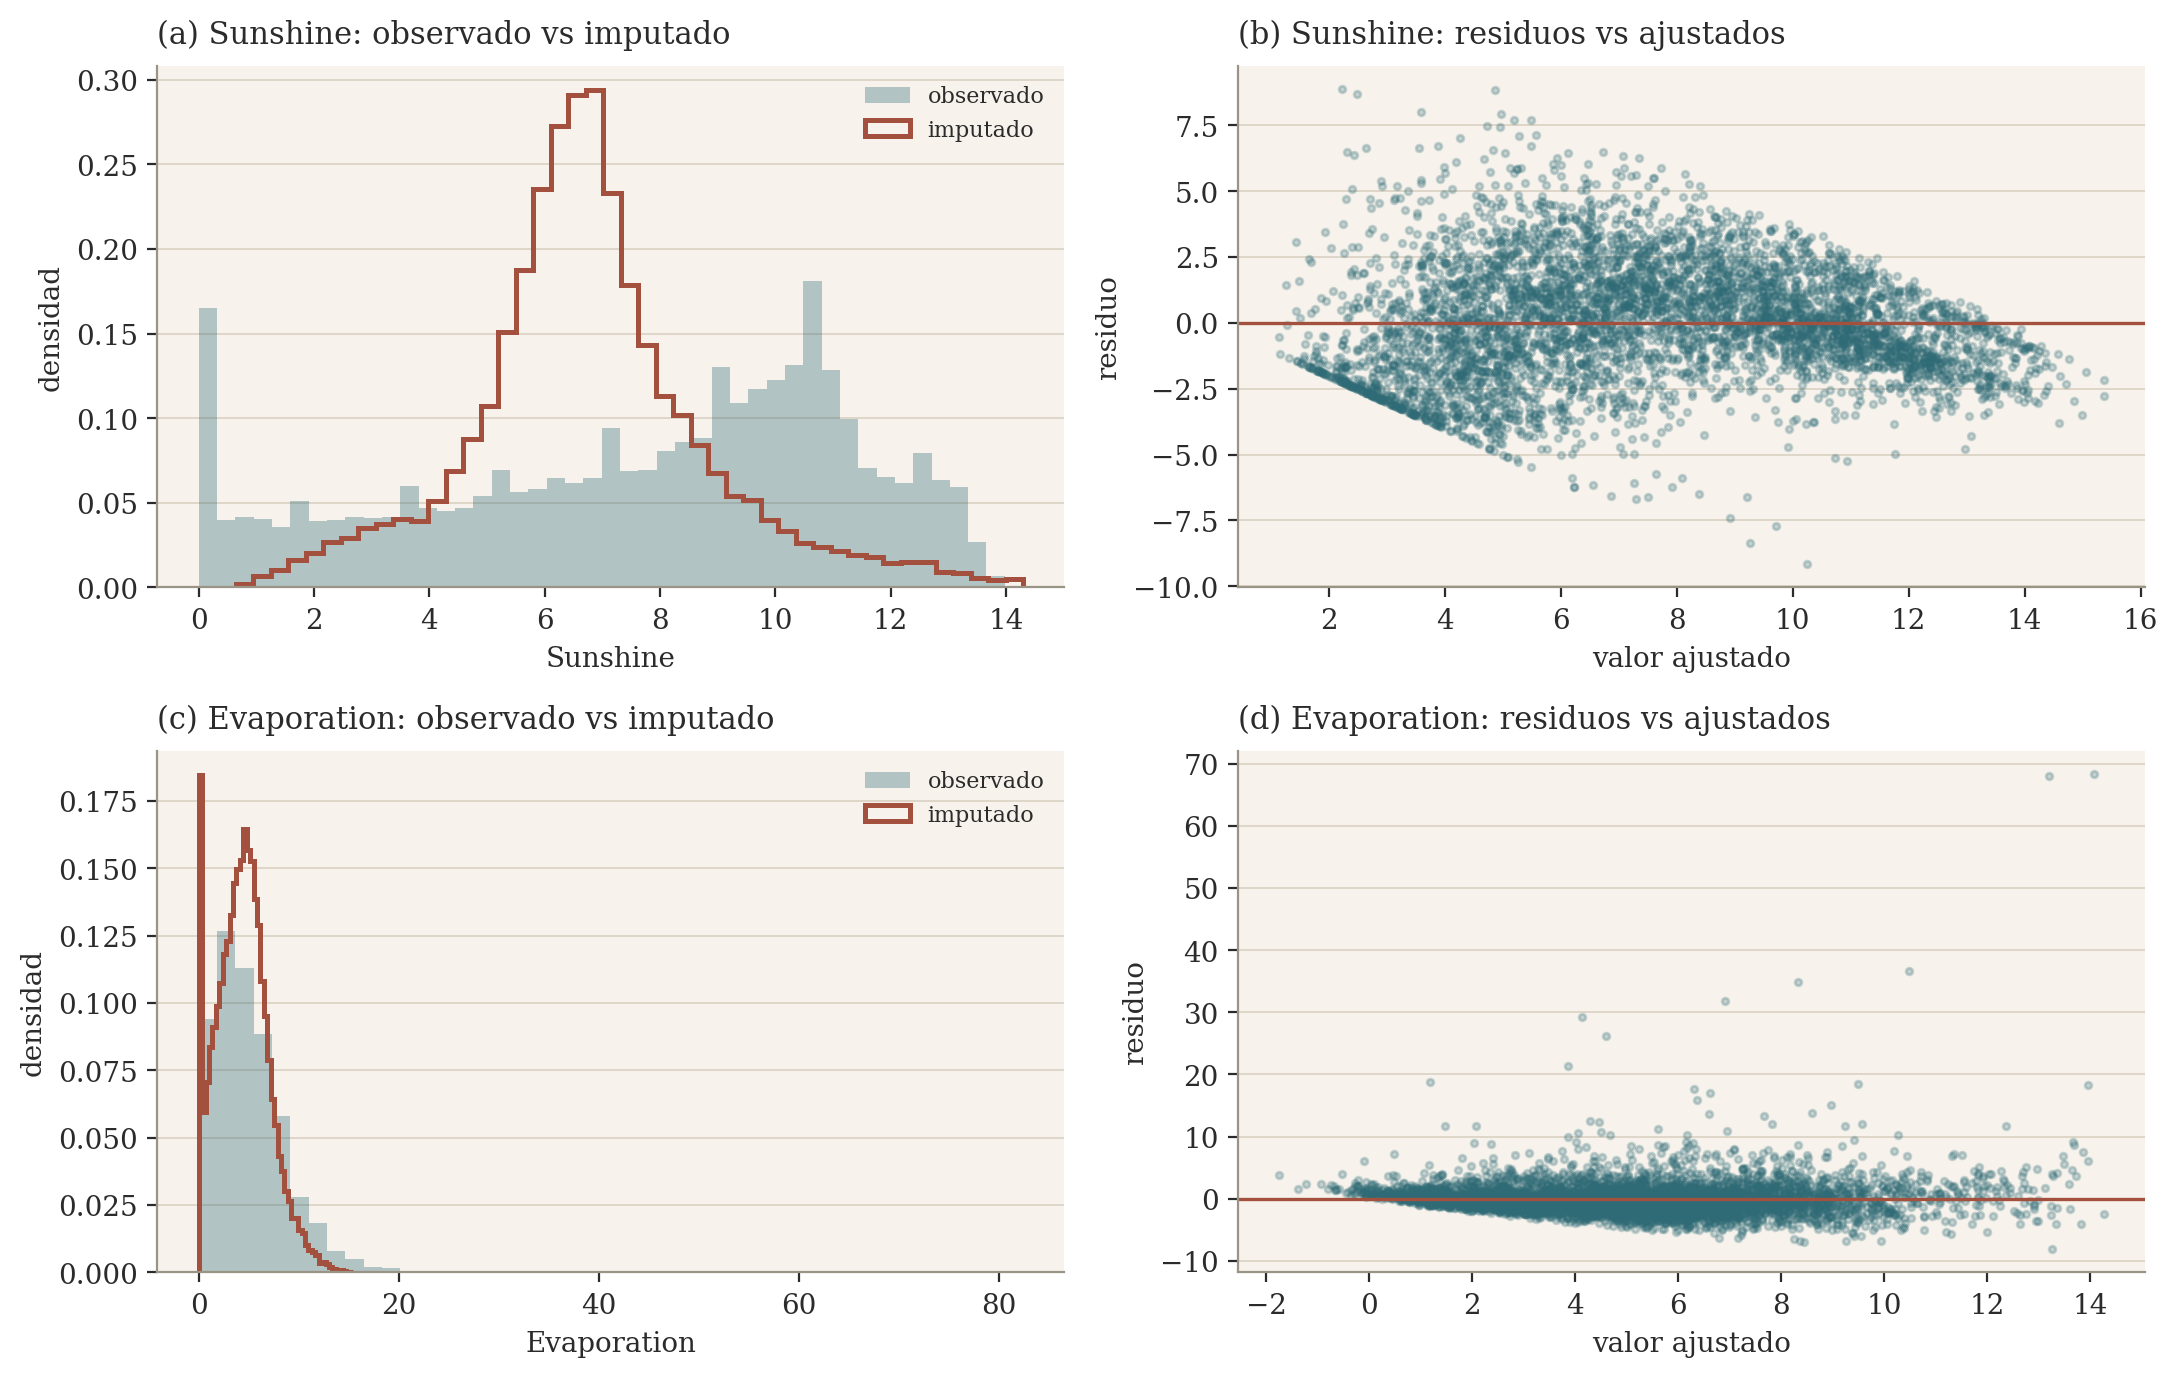

In [3]:
# -----------------------------------------------------------------------------
# 2. Imputación por regresión ajustada únicamente con el entrenamiento temporal
# -----------------------------------------------------------------------------
NUMERIC_ORIGINAL = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
    'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
]
# La matriz de S1 incluyó las variables meteorológicas originales y RainToday_bin.
PREDICTOR_POOL = NUMERIC_ORIGINAL + ['RainToday_bin']
STABLE_S2 = {'Humidity3pm', 'RainToday_bin', 'Humidity9am', 'Pressure9am', 'Rainfall'}

# Matriz de correlaciones heredada de S1. Se usa solo para seleccionar candidatos;
# los modelos y sus parámetros se ajustan exclusivamente en entrenamiento.
MATRIZ_CORRELACIONES_S1 = df[PREDICTOR_POOL].corr(numeric_only=True)

def seleccionar_predictores_imputacion(train: pd.DataFrame, target: str, max_pred: int = 5):
    candidatos = []
    if target not in MATRIZ_CORRELACIONES_S1.columns:
        return [], {}
    for pred, corr_s1 in MATRIZ_CORRELACIONES_S1[target].drop(labels=[target]).dropna().items():
        if pred not in train.columns:
            continue
        sub = train[[target, pred]].dropna()
        if len(sub) < 1000 or sub[target].nunique() < 2 or sub[pred].nunique() < 2:
            continue
        # S2 actúa como criterio de prioridad, sin reemplazar la matriz de S1.
        puntaje = abs(float(corr_s1)) + (0.02 if pred in STABLE_S2 else 0.0)
        candidatos.append((puntaje, abs(float(corr_s1)), pred, float(corr_s1)))
    candidatos.sort(reverse=True)
    seleccionados = [fila[2] for fila in candidatos[:max_pred]]
    correlaciones = {fila[2]: fila[3] for fila in candidatos[:max_pred]}
    return seleccionados, correlaciones

def aplicar_restricciones_dominio(values: np.ndarray, target: str, observed_train: pd.Series) -> np.ndarray:
    lo = float(observed_train.min()); hi = float(observed_train.max())
    values = np.clip(values, lo, hi)
    if target in ['Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']:
        values = np.clip(values, 0, None)
    if target in ['Humidity9am', 'Humidity3pm']:
        values = np.clip(values, 0, 100)
    if target in ['Cloud9am', 'Cloud3pm']:
        values = np.clip(np.rint(values), 0, 8)
    return values

def imputar_por_regresion_entrenamiento_prueba(train: pd.DataFrame, test: pd.DataFrame):
    tr = train.copy(); te = test.copy()
    summary_rows = []; models = {}

    # RainToday es categórica binaria: moda del entrenamiento.
    rain_mode = float(tr['RainToday_bin'].mode(dropna=True).iloc[0])
    tr['RainToday_bin'] = tr['RainToday_bin'].fillna(rain_mode)
    te['RainToday_bin'] = te['RainToday_bin'].fillna(rain_mode)

    for target in NUMERIC_ORIGINAL:
        nmiss_tr = int(tr[target].isna().sum()); nmiss_te = int(te[target].isna().sum())
        if nmiss_tr + nmiss_te == 0:
            continue

        predictors, corr_s1 = seleccionar_predictores_imputacion(train, target, max_pred=5)
        columnas = ['Date', target] + predictors
        complete = train[columnas].dropna().sort_values('Date').copy()

        if len(complete) < 1000 or len(predictors) < 3:
            median = float(train[target].median())
            tr[target] = tr[target].fillna(median); te[target] = te[target].fillna(median)
            summary_rows.append([
                target, nmiss_tr, nmiss_te, 'mediana de respaldo', ' | '.join(predictors),
                ' | '.join(f'{p}:{corr_s1[p]:.3f}' for p in predictors),
                np.nan, np.nan, np.nan, np.nan, np.nan, len(complete)
            ])
            continue

        corte = max(1, int(len(complete) * 0.80))
        ajuste = complete.iloc[:corte]
        validacion = complete.iloc[corte:]
        X_fit, y_fit = ajuste[predictors], ajuste[target]
        X_val, y_val = validacion[predictors], validacion[target]

        validation_model = LinearRegression().fit(X_fit, y_fit)
        validation_pred = validation_model.predict(X_val)
        r2_val = float(validation_model.score(X_val, y_val))
        rmse_val = float(np.sqrt(np.mean((y_val - validation_pred) ** 2)))

        final_model = LinearRegression().fit(complete[predictors], complete[target])
        fitted = final_model.predict(complete[predictors])
        residuals = complete[target].to_numpy() - fitted
        predictor_medians = train[predictors].median(numeric_only=True)

        for frame in [tr, te]:
            mask = frame[target].isna()
            if mask.any():
                X_missing = frame.loc[mask, predictors].copy().fillna(predictor_medians)
                predicted = final_model.predict(X_missing)
                frame.loc[mask, target] = aplicar_restricciones_dominio(
                    predicted, target, train[target].dropna()
                )

        summary_rows.append([
            target, nmiss_tr, nmiss_te, 'regresión lineal múltiple', ' | '.join(predictors),
            ' | '.join(f'{p}:{corr_s1[p]:.3f}' for p in predictors),
            r2_val, rmse_val, float(np.mean(residuals)), float(stats.skew(residuals)),
            float(np.corrcoef(residuals, fitted)[0, 1]), len(complete),
        ])
        models[target] = {
            'model': final_model, 'predictors': predictors, 'correlaciones_s1': corr_s1,
            'medians': predictor_medians, 'complete': complete,
            'fitted': fitted, 'residuals': residuals,
        }

    summary = pd.DataFrame(summary_rows, columns=[
        'variable', 'imputados_train', 'imputados_test', 'metodo', 'predictores',
        'correlaciones_s1', 'R2_validacion_temporal', 'RMSE_validacion_temporal',
        'residuo_media', 'residuo_asimetria', 'corr_residuo_ajustado',
        'n_completos_ajuste',
    ])
    return tr, te, summary, models

print('ETAPA 2: imputación', flush=True)
train_reg, test_reg, imputation_summary, imputation_models = imputar_por_regresion_entrenamiento_prueba(
    train_raw, test_raw
)
print('Imputación completada', flush=True)
imputation_summary.to_csv(TABLES / 's3_03_imputacion_regresion.csv', index=False)

# Imputación simple con medianas/moda aprendidas exclusivamente en entrenamiento.
train_simple = train_raw.copy(); test_simple = test_raw.copy()
for col in NUMERIC_ORIGINAL:
    med = float(train_raw[col].median())
    train_simple[col] = train_simple[col].fillna(med)
    test_simple[col] = test_simple[col].fillna(med)
rain_mode = float(train_raw['RainToday_bin'].mode(dropna=True).iloc[0])
train_simple['RainToday_bin'] = train_simple['RainToday_bin'].fillna(rain_mode)
test_simple['RainToday_bin'] = test_simple['RainToday_bin'].fillna(rain_mode)

# Transformación recomendada por S2 para la variable cero-inflada y asimétrica.
for tr, te in [(train_reg, test_reg), (train_simple, test_simple)]:
    tr['Rainfall_log1p'] = np.log1p(tr['Rainfall'].clip(lower=0))
    te['Rainfall_log1p'] = np.log1p(te['Rainfall'].clip(lower=0))
train_drop = train_raw.copy(); test_drop = test_raw.copy()
train_drop['Rainfall_log1p'] = np.log1p(train_drop['Rainfall'].clip(lower=0))
test_drop['Rainfall_log1p'] = np.log1p(test_drop['Rainfall'].clip(lower=0))

# Diagnóstico de las variables críticas destacadas en la retroalimentación.
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for row, target in enumerate(['Sunshine', 'Evaporation']):
    info = imputation_models[target]
    observed = info['complete'][target]
    mask = train_raw[target].isna()
    X_missing = train_raw.loc[mask, info['predictors']].copy().fillna(info['medians'])
    imputed = aplicar_restricciones_dominio(
        info['model'].predict(X_missing), target, train_raw[target].dropna()
    )
    axes[row, 0].hist(observed, bins=45, density=True, color=TEAL, alpha=0.35, label='observado')
    axes[row, 0].hist(imputed, bins=45, density=True, histtype='step', color=BRICK, lw=1.8, label='imputado')
    axes[row, 0].set_title(f'({chr(97+row*2)}) {target}: observado vs imputado')
    axes[row, 0].set_xlabel(target); axes[row, 0].set_ylabel('densidad')
    aplicar_rejilla_horizontal(axes[row, 0]); axes[row, 0].legend(frameon=False, fontsize=8)
    sample_n = min(5000, len(info['fitted']))
    idx = rng.choice(len(info['fitted']), sample_n, replace=False)
    axes[row, 1].scatter(info['fitted'][idx], info['residuals'][idx], s=6, alpha=0.25, color=TEAL)
    axes[row, 1].axhline(0, color=BRICK, lw=1.2)
    axes[row, 1].set_title(f'({chr(98+row*2)}) {target}: residuos vs ajustados')
    axes[row, 1].set_xlabel('valor ajustado'); axes[row, 1].set_ylabel('residuo')
    aplicar_rejilla_horizontal(axes[row, 1])
fig.tight_layout()
fig.savefig(FIGS / 's3_fig1_imputacion_diagnostico.png', bbox_inches='tight')
plt.close(fig)

# Preservación de distribución y correlación con el objetivo en variables críticas.
critical_vars = ['Sunshine', 'Evaporation', 'Humidity3pm', 'Pressure9am', 'Rainfall_log1p']
prelim_rows = []
for name, tr, te in [
    ('Eliminación (observados)', train_drop, test_drop),
    ('Imputación simple', train_simple, test_simple),
    ('Imputación por regresión', train_reg, test_reg),
]:
    combined = pd.concat([tr, te], ignore_index=True)
    for var in critical_vars:
        s = combined[var].dropna()
        corr_df = combined[[var, 'RainTomorrow_bin']].dropna()
        prelim_rows.append([
            name, var, len(s), float(s.mean()), float(s.median()), float(s.std()),
            float(corr_df[var].corr(corr_df['RainTomorrow_bin']))
        ])
prelim_compare = pd.DataFrame(prelim_rows, columns=[
    'estrategia', 'variable', 'n_valido', 'media', 'mediana',
    'desv_est', 'corr_objetivo'
])
prelim_compare.to_csv(TABLES / 's3_04_comparacion_distribuciones_imputacion.csv', index=False)

print('Resumen de modelos de imputación:')
display(imputation_summary.sort_values('imputados_train', ascending=False))
print('Preservación preliminar de distribución y correlación:')
display(prelim_compare)
display(Image(filename=str(FIGS / 's3_fig1_imputacion_diagnostico.png')))


# Parte 2. Clasificación mediante regresión logística

## 2.1 Preparación informada por S1 y S2

- Se aplica `log1p` a `Rainfall`, porque S2 confirmó su cola derecha extrema y cero-inflación.
- Se winsoriza únicamente `WindGustSpeed` en percentiles 1–99 aprendidos en entrenamiento.
- No se incluyen simultáneamente `MaxTemp` y `Temp3pm`; el control VIF elimina además predictores redundantes.
- Las variables se estandarizan con parámetros calculados solo en entrenamiento.
- `RainToday` se codifica como 0/1. Las variables categóricas de dirección y `Location` no se incorporan como predictores en esta línea base; `Location` se utiliza para validación espacial.
- La inferencia de coeficientes se realiza sin ponderación y utiliza intervalos de Wald derivados de la matriz de información observada; `class_weight='balanced'` se reserva para clasificación.

## 2.2 Modelos solicitados

1. **M1 Dominio S1/S2:** predictores sustentados por las fases anteriores.
2. **M2 Stepwise:** selección escalonada hacia atrás por significancia.
3. **M3 BIC:** comparación de modelos anidados ordenados por asociación con la respuesta y selección del mínimo BIC.
4. **M4 Reducido:** alternativa parsimoniosa derivada de la trayectoria BIC.

Stepwise y BIC se ejecutan y reportan por separado sobre una muestra sistemática de 30.000 observaciones del entrenamiento para mantener una ejecución reproducible en tiempo razonable. Las especificaciones resultantes se reajustan con todo el entrenamiento.

## 2.3 Validación y desempeño

La comparación utiliza validación temporal interna con `TimeSeriesSplit`. El 30 % cronológicamente más reciente permanece como prueba externa y no interviene en la selección. Una validación agrupada por `Location` se conserva como extensión recomendada, porque su costo de ejecución es considerable y la rúbrica permite partición temporal o agrupada.

Se reportan matrices de confusión, exactitud, precisión, sensibilidad, especificidad, F1, ROC-AUC y PR-AUC.


ETAPA 3: selección y validación de modelos


Modelos evaluados


Control VIF previo a selección:


,variable_eliminada,VIF_previo,variables_antes
0,Pressure3pm,19.006045,Humidity3pm | RainToday_bin | Humidity9am | Pr...


Trayectoria stepwise:


...

,paso,variable_ingresa,variables_modelo,asociacion_abs_objetivo,AIC,BIC
0,1,Humidity3pm,Humidity3pm,0.455291,25257.584961,25274.202866
1,2,Sunshine,Humidity3pm | Sunshine,0.408928,24581.313888,24606.240746
2,3,Cloud3pm,Humidity3pm | Sunshine | Cloud3pm,0.369833,24366.662589,24399.898400
3,4,Rainfall_log1p,Humidity3pm | Sunshine | Cloud3pm | Rainfall_l...,0.352954,23723.367313,23764.912076
4,5,RainToday_bin,Humidity3pm | Sunshine | Cloud3pm | Rainfall_l...,0.315788,23724.696577,23774.550293
5,6,Cloud9am,Humidity3pm | Sunshine | Cloud3pm | Rainfall_l...,0.312556,23723.177258,23781.339926
6,7,Humidity9am,Humidity3pm | Sunshine | Cloud3pm | Rainfall_l...,0.270773,23652.513912,23718.985533
7,8,Pressure9am,Humidity3pm | Sunshine | Cloud3pm | Rainfall_l...,0.237046,22701.359353,22776.139927
8,9,WindGustSpeed,Humidity3pm | Sunshine | Cloud3pm | Rainfall_l...,0.213944,22166.916392,22250.005918
9,10,Temp3pm,Humidity3pm | Sunshine | Cloud3pm | Rainfall_l...,0.195258,22024.843492,22116.241971


Desempeño y validaciones de los cuatro modelos:


,modelo,particion,n_variables,cv_temporal_auc_media,cv_temporal_auc_sd,accuracy,precision,recall,specificity,f1,auc,pr_auc,tn,fp,fn,tp
0,M1 Dominio S1/S2,train,5,0.845722,0.003252,0.773894,0.502917,0.755169,0.779428,0.603754,0.846835,0.668369,55998,15847,5198,16033
1,M1 Dominio S1/S2,test,5,0.845722,0.003252,0.776554,0.489506,0.720740,0.791999,0.583033,0.833725,0.631293,30469,8002,2973,7673
2,M2 Stepwise,train,13,0.864976,0.004421,0.789548,0.526387,0.771890,0.794767,0.625926,0.867021,0.695582,57100,14745,4843,16388
3,M2 Stepwise,test,13,0.864976,0.004421,0.784677,0.502222,0.743190,0.796158,0.599394,0.851827,0.655475,30629,7842,2734,7912
4,M3 BIC,train,14,0.864969,0.004428,0.789441,0.526225,0.771702,0.794683,0.625750,0.867024,0.695562,57094,14751,4847,16384
5,M3 BIC,test,14,0.864969,0.004428,0.784637,0.502158,0.743096,0.796132,0.599318,0.851822,0.655455,30628,7843,2735,7911
6,M4 Reducido,train,8,0.849969,0.003367,0.773357,0.502113,0.760963,0.777020,0.605014,0.851471,0.671825,55825,16020,5075,16156
7,M4 Reducido,test,8,0.849969,0.003367,0.770487,0.480442,0.723370,0.783525,0.577395,0.832256,0.625077,30143,8328,2945,7701


Coeficientes, OR e IC de Wald:


,modelo,variable,coef,IC95_coef_inf,IC95_coef_sup,OR,IC95_OR_inf,IC95_OR_sup,p_value
0,M1 Dominio S1/S2,const,-1.749319,-1.778505,-1.720134,0.173892,0.168890,0.179042,0.000000e+00
1,M1 Dominio S1/S2,Humidity3pm,1.303808,1.279733,1.327884,3.683298,3.595680,3.773051,0.000000e+00
2,M1 Dominio S1/S2,RainToday_bin,0.032371,-0.046032,0.110775,1.032901,0.955011,1.117143,4.183816e-01
3,M1 Dominio S1/S2,Pressure9am,-0.355947,-0.376600,-0.335294,0.700510,0.686191,0.715128,3.979636e-250
4,M1 Dominio S1/S2,Rainfall_log1p,0.276029,0.242759,0.309298,1.317886,1.274762,1.362469,1.856851e-59
5,M1 Dominio S1/S2,WindGustSpeed,0.446713,0.426738,0.466687,1.563165,1.532252,1.594703,0.000000e+00
6,M2 Stepwise,const,-1.818321,-1.842084,-1.794559,0.162298,0.158487,0.166201,0.000000e+00
7,M2 Stepwise,Humidity3pm,1.074679,1.042526,1.106832,2.929052,2.836374,3.024759,0.000000e+00
8,M2 Stepwise,Humidity9am,0.095248,0.062236,0.128260,1.099932,1.064213,1.136849,1.558940e-08
9,M2 Stepwise,Pressure9am,-0.347655,-0.370319,-0.324992,0.706342,0.690514,0.722533,1.360710e-198


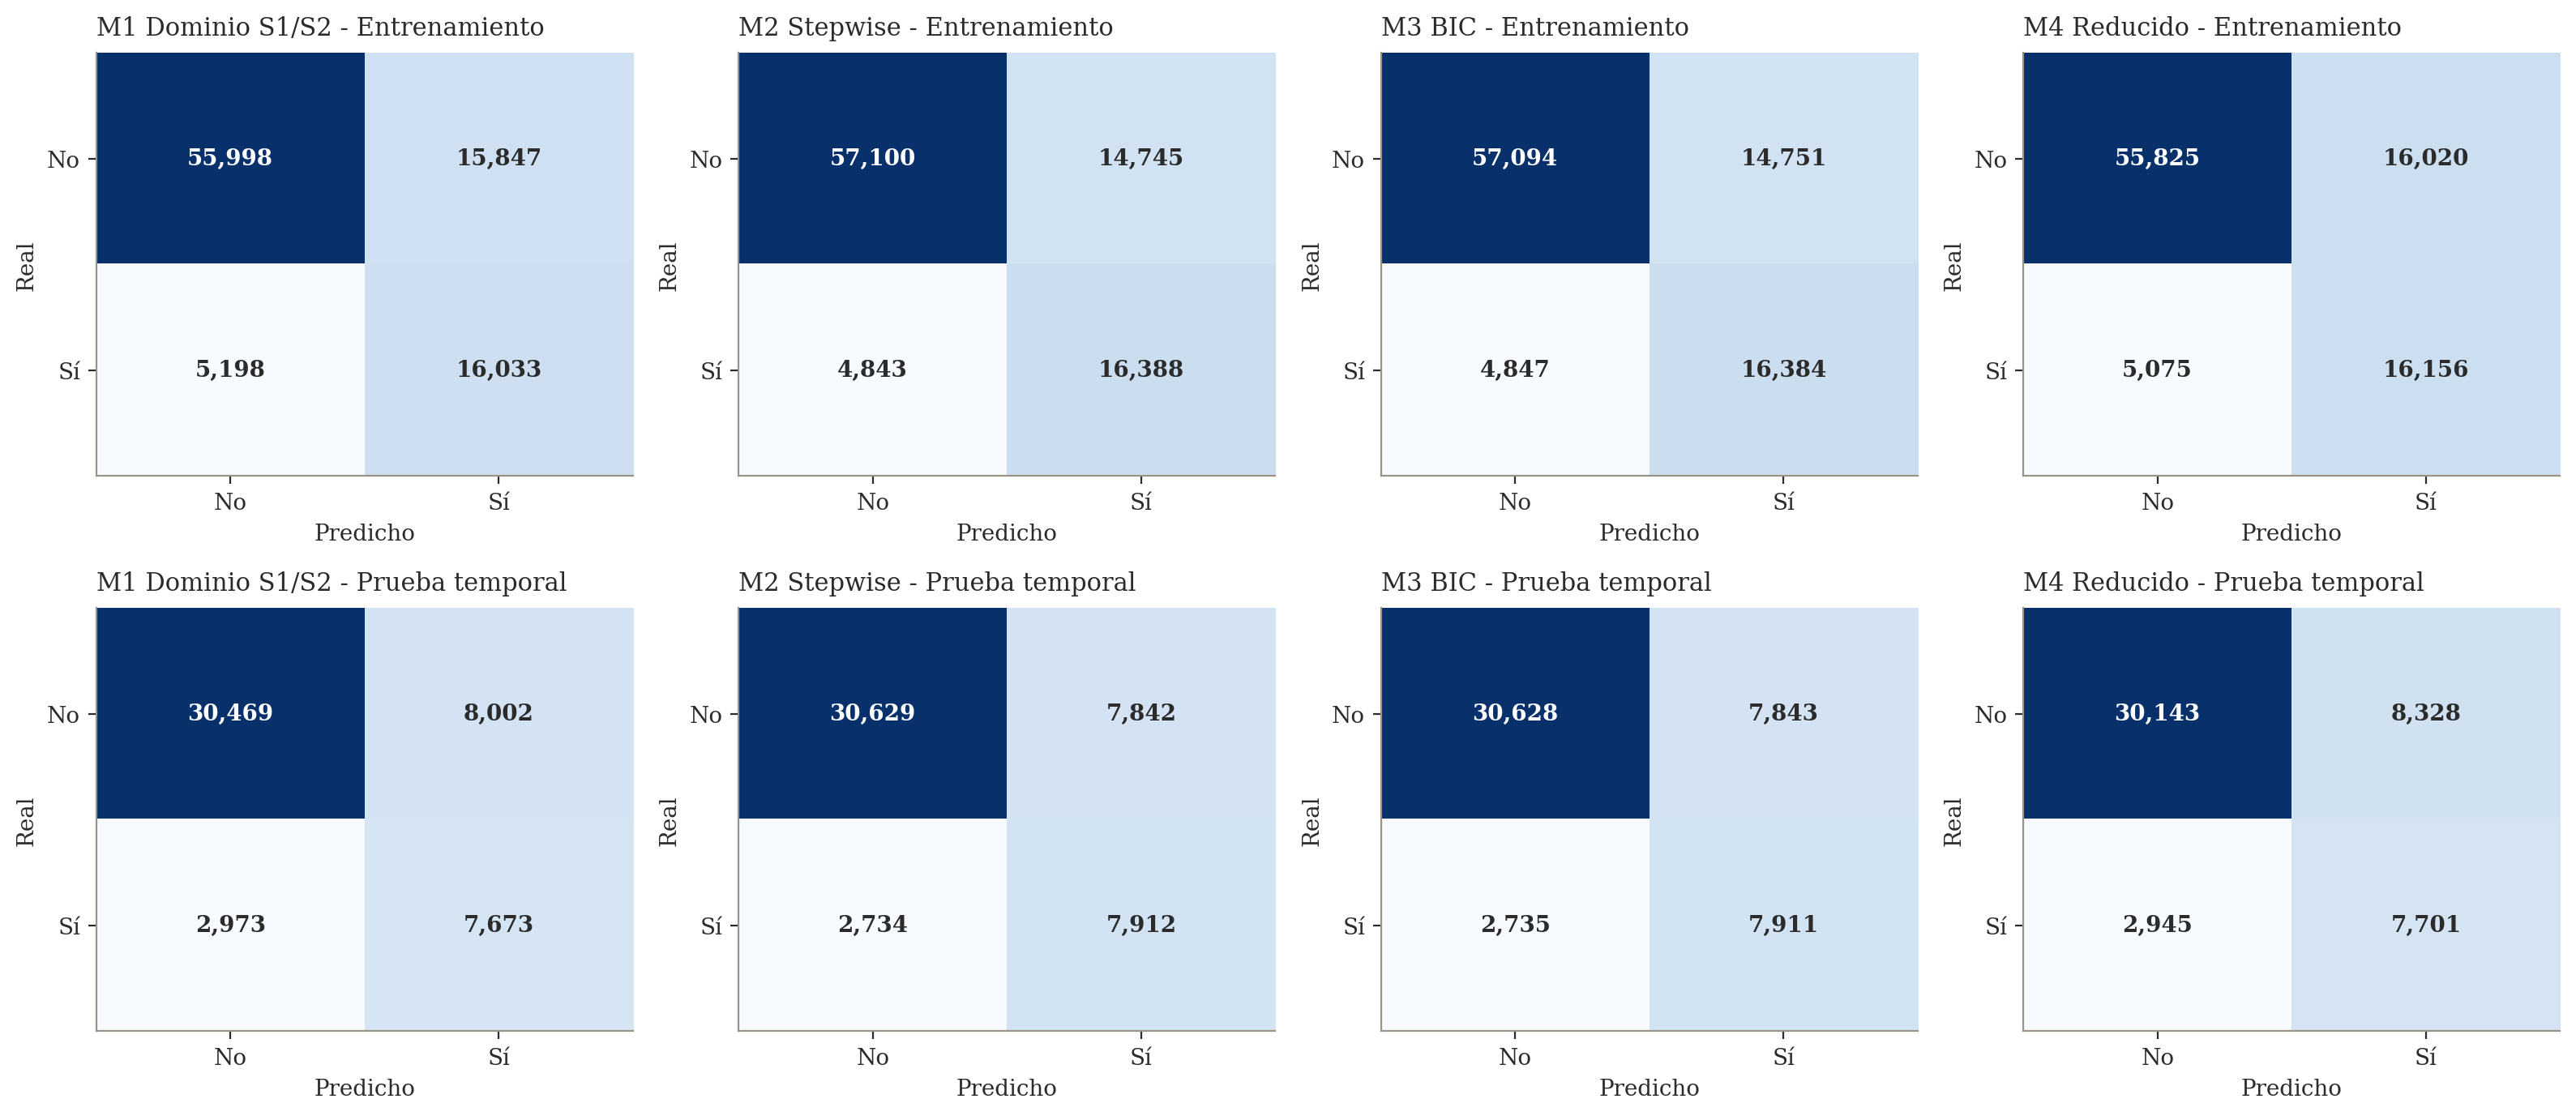

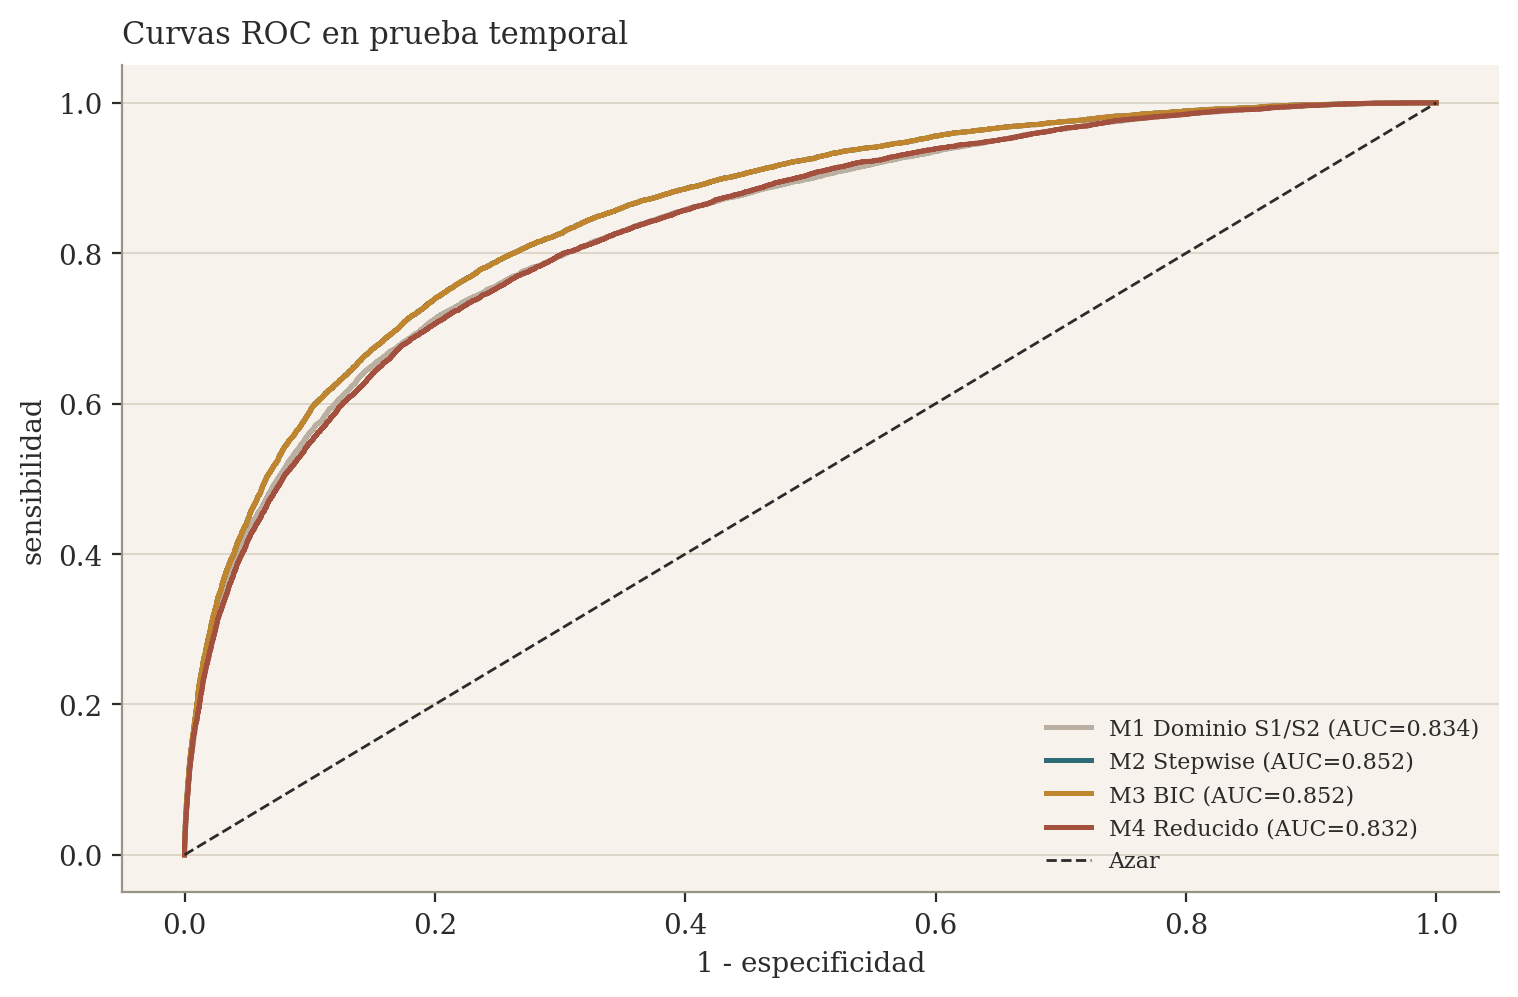

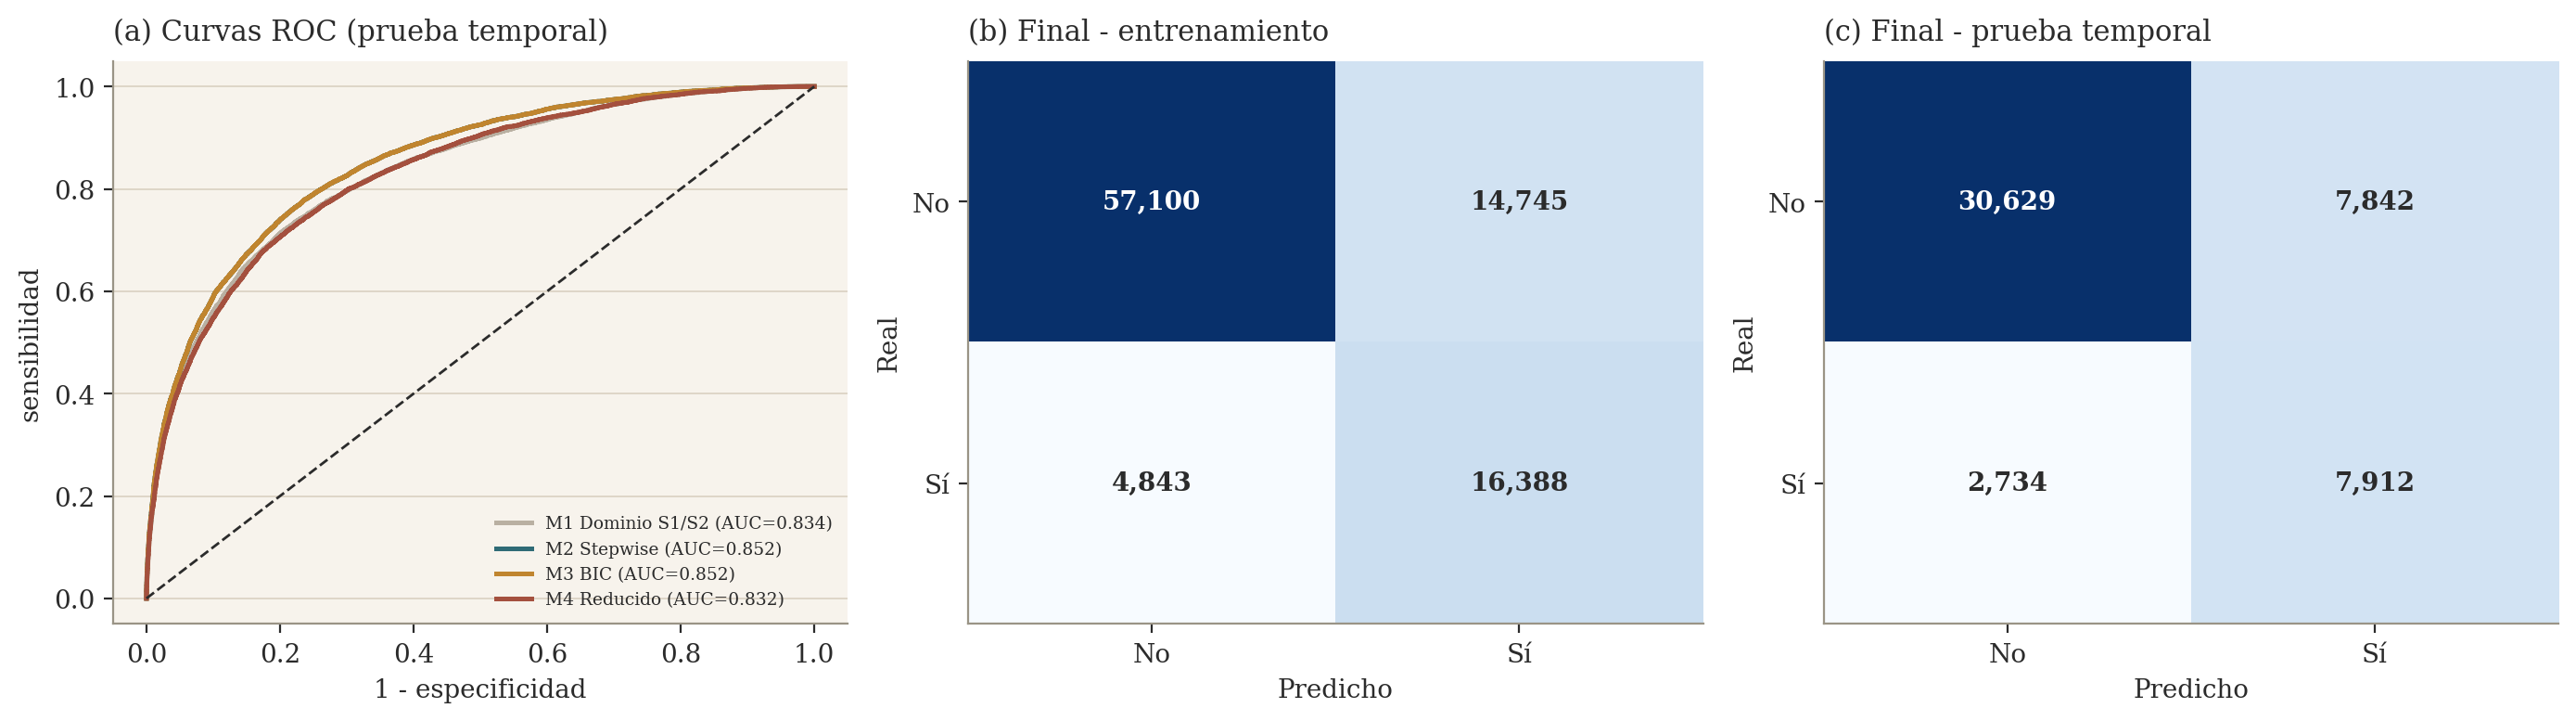

In [4]:
# -----------------------------------------------------------------------------
# 3. Preparación, selección, validación y evaluación de modelos
# -----------------------------------------------------------------------------
CANDIDATES = [
    'Humidity3pm', 'RainToday_bin', 'Humidity9am', 'Pressure9am', 'Pressure3pm',
    'Rainfall_log1p', 'WindGustSpeed', 'Sunshine', 'Evaporation', 'Cloud3pm',
    'Cloud9am', 'Temp3pm', 'WindSpeed3pm', 'Month_sin', 'Month_cos',
]
DOMAIN_FEATURES = [
    'Humidity3pm', 'RainToday_bin', 'Pressure9am',
    'Rainfall_log1p', 'WindGustSpeed'
]

def preprocesar_estrategia(
    train: pd.DataFrame,
    test: pd.DataFrame,
    features: list[str],
    drop_missing: bool = False,
):
    tr = train.copy(); te = test.copy()
    if drop_missing:
        tr = tr.dropna(subset=features + ['RainTomorrow_bin']).copy()
        te = te.dropna(subset=features + ['RainTomorrow_bin']).copy()

    # Respaldo preventivo con medianas aprendidas únicamente en entrenamiento.
    for col in features:
        if tr[col].isna().any() or te[col].isna().any():
            med = float(tr[col].median())
            tr[col] = tr[col].fillna(med)
            te[col] = te[col].fillna(med)

    # Tratamiento robusto heredado de S1/S2.
    if 'WindGustSpeed' in features:
        low, high = tr['WindGustSpeed'].quantile([0.01, 0.99])
        tr['WindGustSpeed'] = tr['WindGustSpeed'].clip(low, high)
        te['WindGustSpeed'] = te['WindGustSpeed'].clip(low, high)

    continuous = [c for c in features if c != 'RainToday_bin']
    scaler = StandardScaler().fit(tr[continuous])
    X_train = tr[features].copy(); X_test = te[features].copy()
    X_train[continuous] = scaler.transform(tr[continuous])
    X_test[continuous] = scaler.transform(te[continuous])
    y_train = tr['RainTomorrow_bin'].astype(int).to_numpy()
    y_test = te['RainTomorrow_bin'].astype(int).to_numpy()
    return (
        X_train.reset_index(drop=True),
        X_test.reset_index(drop=True),
        y_train,
        y_test,
        tr.reset_index(drop=True),
        te.reset_index(drop=True),
        scaler,
    )

print('ETAPA 3: selección y validación de modelos', flush=True)
X_train_all, X_test_all, y_train, y_test, train_model_df, test_model_df, scaler_all = preprocesar_estrategia(
    train_reg, test_reg, CANDIDATES
)

def calcular_vif(X: pd.DataFrame, features: list[str]) -> pd.Series:
    arr = X[features].to_numpy()
    return pd.Series(
        [variance_inflation_factor(arr, i) for i in range(arr.shape[1])],
        index=features,
    )

def controlar_vif(features: list[str], X: pd.DataFrame, threshold: float = 5.0):
    selected = list(features); history = []
    priority = STABLE_S2 | {'Rainfall_log1p'}
    while len(selected) > 2:
        vif = calcular_vif(X, selected)
        if float(vif.max()) <= threshold:
            break
        high = vif[vif > threshold].sort_values(ascending=False)
        nonpriority = [v for v in high.index if v not in priority]
        drop = nonpriority[0] if nonpriority else str(high.index[0])
        history.append([drop, float(vif[drop]), ' | '.join(selected)])
        selected.remove(drop)
    return selected, pd.DataFrame(
        history,
        columns=['variable_eliminada', 'VIF_previo', 'variables_antes'],
    )

POOL_VIF, vif_selection_history = controlar_vif(CANDIDATES, X_train_all, threshold=5.0)
vif_selection_history.to_csv(TABLES / 's3_05_control_vif_seleccion.csv', index=False)

class ResultadoLogitRapido:
    """Resultado mínimo compatible con tablas de inferencia de Wald."""

    def __init__(
        self,
        nombres: list[str],
        parametros: np.ndarray,
        errores: np.ndarray,
        p_valores: np.ndarray,
        aic: float,
        bic: float,
    ):
        self.params = pd.Series(parametros, index=nombres, dtype=float)
        self.bse = pd.Series(errores, index=nombres, dtype=float)
        self.pvalues = pd.Series(p_valores, index=nombres, dtype=float)
        self.aic = float(aic)
        self.bic = float(bic)
        self.bic_llf = float(bic)

    def conf_int(self, alpha: float = 0.05) -> pd.DataFrame:
        z = stats.norm.ppf(1 - alpha / 2)
        return pd.DataFrame({
            0: self.params - z * self.bse,
            1: self.params + z * self.bse,
        })


def ajustar_logit_inferencia(
    X: pd.DataFrame,
    y: np.ndarray,
    features: list[str],
):
    """Ajuste logístico rápido e inferencia de Wald sin ponderación.

    El modelo se ajusta con penalización prácticamente nula (C=1e6). Los
    errores estándar se obtienen de la inversa de la matriz de información
    observada X'WX, equivalente a la aproximación asintótica usual.
    """
    model = LogisticRegression(
        C=1e6,
        solver='liblinear',
        max_iter=500,
        tol=1e-5,
        random_state=SEED,
    )
    model.fit(X[features], y)

    parametros = np.concatenate(([model.intercept_[0]], model.coef_[0]))
    nombres = ['const'] + list(features)
    X_diseno = np.column_stack([np.ones(len(X)), X[features].to_numpy()])
    prob = np.clip(model.predict_proba(X[features])[:, 1], 1e-9, 1 - 1e-9)
    pesos = prob * (1 - prob)
    informacion = X_diseno.T @ (X_diseno * pesos[:, None])
    covarianza = np.linalg.pinv(informacion)
    errores = np.sqrt(np.clip(np.diag(covarianza), 0, None))
    estadisticos_z = parametros / errores
    p_valores = 2 * stats.norm.sf(np.abs(estadisticos_z))

    loglik = float(np.sum(y * np.log(prob) + (1 - y) * np.log(1 - prob)))
    k = len(parametros); n = len(y)
    aic = 2 * k - 2 * loglik
    bic = math.log(n) * k - 2 * loglik
    return ResultadoLogitRapido(
        nombres, parametros, errores, p_valores, aic, bic
    )

def seleccion_escalonada_hacia_atras_pvalor(
    X: pd.DataFrame,
    y: np.ndarray,
    features: list[str],
    p_remove: float = 0.05,
):
    selected = list(features); history = []
    while len(selected) > 1:
        result = ajustar_logit_inferencia(X, y, selected)
        pvals = result.pvalues.drop('const')
        worst_var = str(pvals.idxmax()); worst_p = float(pvals.max())
        if worst_p <= p_remove:
            break
        history.append([
            len(history) + 1,
            worst_var,
            worst_p,
            float(result.aic),
            float(result.bic_llf),
        ])
        selected.remove(worst_var)
    return selected, pd.DataFrame(
        history,
        columns=['paso', 'variable_eliminada', 'p_value', 'AIC', 'BIC'],
    )

def calcular_criterios_informacion_subconjunto(
    X: pd.DataFrame,
    y: np.ndarray,
    features: list[str],
):
    result = ajustar_logit_inferencia(X, y, features)
    return float(result.aic), float(result.bic)

def seleccion_modelo_bic_anidado(
    X: pd.DataFrame,
    y: np.ndarray,
    candidates: list[str],
):
    # Orden inicial por asociación absoluta con la respuesta dentro de la
    # muestra de selección. Luego se comparan modelos anidados mediante BIC.
    asociaciones = {
        variable: abs(float(np.corrcoef(X[variable], y)[0, 1]))
        for variable in candidates
    }
    ranking = sorted(candidates, key=lambda v: asociaciones[v], reverse=True)
    history = []
    for k in range(1, len(ranking) + 1):
        features = ranking[:k]
        aic, bic = calcular_criterios_informacion_subconjunto(X, y, features)
        history.append([
            k,
            ranking[k - 1],
            ' | '.join(features),
            asociaciones[ranking[k - 1]],
            aic,
            bic,
        ])
    history_df = pd.DataFrame(
        history,
        columns=[
            'paso', 'variable_ingresa', 'variables_modelo',
            'asociacion_abs_objetivo', 'AIC', 'BIC',
        ],
    )
    best_k = int(history_df.loc[history_df['BIC'].idxmin(), 'paso'])
    return ranking[:best_k], history_df

# Para que Restart & Run All sea viable, la búsqueda stepwise/BIC se realiza
# sobre una muestra sistemática de 30.000 observaciones distribuida a lo largo
# de todo el entrenamiento. La especificación elegida se reajusta después con
# las 93.076 observaciones completas del entrenamiento.
SELECTION_N = min(30000, len(y_train))
selection_idx = np.linspace(0, len(y_train) - 1, SELECTION_N, dtype=int)
X_selection = X_train_all.iloc[selection_idx].reset_index(drop=True)
y_selection = y_train[selection_idx]

STEPWISE_FEATURES, stepwise_history = seleccion_escalonada_hacia_atras_pvalor(
    X_selection, y_selection, POOL_VIF, p_remove=0.05
)
BIC_FEATURES, bic_history = seleccion_modelo_bic_anidado(
    X_selection, y_selection, POOL_VIF
)
stepwise_history.to_csv(TABLES / 's3_06_stepwise_historial.csv', index=False)
bic_history.to_csv(TABLES / 's3_07_bic_historial.csv', index=False)

REDUCED_K = min(8, len(BIC_FEATURES))
REDUCED_FEATURES = BIC_FEATURES[:REDUCED_K]

MODEL_SPECS = {
    'M1 Dominio S1/S2': DOMAIN_FEATURES,
    'M2 Stepwise': STEPWISE_FEATURES,
    'M3 BIC': BIC_FEATURES,
    'M4 Reducido': REDUCED_FEATURES,
}

def crear_tabla_coeficientes(result, model_name: str) -> pd.DataFrame:
    ci = result.conf_int()
    return pd.DataFrame({
        'modelo': model_name,
        'variable': result.params.index,
        'coef': result.params.values,
        'IC95_coef_inf': ci.iloc[:, 0].values,
        'IC95_coef_sup': ci.iloc[:, 1].values,
        'OR': np.exp(result.params.values),
        'IC95_OR_inf': np.exp(ci.iloc[:, 0].values),
        'IC95_OR_sup': np.exp(ci.iloc[:, 1].values),
        'p_value': result.pvalues.values,
    })

def calcular_metricas_clasificacion(
    y_true: np.ndarray,
    proba: np.ndarray,
    threshold: float = 0.5,
):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_true, pred, labels=[0, 1]
    ).ravel()
    specificity = tn / (tn + fp)
    return {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'specificity': specificity,
        'f1': f1_score(y_true, pred, zero_division=0),
        'auc': roc_auc_score(y_true, proba),
        'pr_auc': average_precision_score(y_true, proba),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def crear_modelo_predictivo():
    return LogisticRegression(
        C=1e6,
        solver='liblinear',
        max_iter=300,
        class_weight='balanced',
        tol=1e-5,
    )

def evaluar_auc_temporal(
    X: pd.DataFrame,
    y: np.ndarray,
    features: list[str],
    n_splits: int = 5,
):
    scores = []
    splitter = TimeSeriesSplit(n_splits=n_splits)
    for idx_train, idx_val in splitter.split(X):
        if len(np.unique(y[idx_val])) < 2:
            continue
        model = crear_modelo_predictivo()
        model.fit(X.iloc[idx_train][features], y[idx_train])
        p_val = model.predict_proba(X.iloc[idx_val][features])[:, 1]
        scores.append(roc_auc_score(y[idx_val], p_val))
    return np.asarray(scores, dtype=float)


model_objects = {}; performance_rows = []; coefficient_tables = []
for model_name, features in MODEL_SPECS.items():
    inference = ajustar_logit_inferencia(X_train_all, y_train, features)
    predictive = crear_modelo_predictivo()
    predictive.fit(X_train_all[features], y_train)

    cv_temporal = evaluar_auc_temporal(X_train_all, y_train, features, n_splits=5)

    p_train = predictive.predict_proba(X_train_all[features])[:, 1]
    p_test = predictive.predict_proba(X_test_all[features])[:, 1]
    model_objects[model_name] = {
        'features': features,
        'inference': inference,
        'predictive': predictive,
        'p_train': p_train,
        'p_test': p_test,
        'cv_temporal': cv_temporal,
    }
    coefficient_tables.append(crear_tabla_coeficientes(inference, model_name))
    for partition, y_true, proba in [
        ('train', y_train, p_train),
        ('test', y_test, p_test),
    ]:
        performance_rows.append({
            'modelo': model_name,
            'particion': partition,
            'n_variables': len(features),
            'cv_temporal_auc_media': float(cv_temporal.mean()),
            'cv_temporal_auc_sd': float(cv_temporal.std()),
            **calcular_metricas_clasificacion(y_true, proba),
        })

print('Modelos evaluados', flush=True)
performance = pd.DataFrame(performance_rows)
coefficients = pd.concat(coefficient_tables, ignore_index=True)
performance.to_csv(TABLES / 's3_08_desempeno_modelos.csv', index=False)
coefficients.to_csv(TABLES / 's3_09_coeficientes_modelos.csv', index=False)

# Selección por validación temporal interna; el test externo no interviene.
rank = performance[performance['particion'] == 'train'][
    ['modelo', 'n_variables', 'cv_temporal_auc_media', 'cv_temporal_auc_sd']
].drop_duplicates()
rank = rank.sort_values(
    ['cv_temporal_auc_media', 'n_variables'],
    ascending=[False, True],
    kind='mergesort',
)

# Si stepwise y BIC convergen, se conserva la etiqueta BIC para el modelo final
# y se informa que ambas rutas producen la misma especificación.
if set(STEPWISE_FEATURES) == set(BIC_FEATURES):
    FINAL_MODEL = 'M3 BIC'
else:
    FINAL_MODEL = str(rank.iloc[0]['modelo'])
FINAL_FEATURES = MODEL_SPECS[FINAL_MODEL]
final = model_objects[FINAL_MODEL]

# Matrices de confusión de todos los modelos.
n_models = len(MODEL_SPECS)
fig, axes = plt.subplots(2, n_models, figsize=(4.0 * n_models, 7))
for col, (model_name, obj) in enumerate(model_objects.items()):
    for row, (partition, y_true, proba) in enumerate([
        ('Entrenamiento', y_train, obj['p_train']),
        ('Prueba temporal', y_test, obj['p_test']),
    ]):
        cm = confusion_matrix(y_true, (proba >= 0.5).astype(int))
        ax = axes[row, col]
        ax.imshow(cm, cmap='Blues', aspect='auto')
        vmax = cm.max()
        for (i, j), value in np.ndenumerate(cm):
            ax.text(
                j, i, f'{value:,}', ha='center', va='center',
                color='white' if value / vmax > 0.55 else INK,
                fontweight='bold',
            )
        ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Sí'])
        ax.set_yticks([0, 1]); ax.set_yticklabels(['No', 'Sí'])
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
        ax.set_title(f'{model_name} - {partition}')
        ax.grid(False)
fig.tight_layout()
fig.savefig(FIGS / 's3_fig2_matrices_confusion_todos.png', bbox_inches='tight')
plt.close(fig)

# Curvas ROC de las cuatro especificaciones.
fig, ax = plt.subplots(figsize=(7.7, 5.1))
colors = [STEM, TEAL, OCHRE, BRICK]
for color, (model_name, obj) in zip(colors, model_objects.items()):
    fpr, tpr, _ = roc_curve(y_test, obj['p_test'])
    auc = roc_auc_score(y_test, obj['p_test'])
    ax.plot(fpr, tpr, lw=1.8, color=color, label=f'{model_name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], color=INK, ls='--', lw=1, label='Azar')
ax.set_xlabel('1 - especificidad'); ax.set_ylabel('sensibilidad')
ax.set_title('Curvas ROC en prueba temporal')
aplicar_rejilla_horizontal(ax)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / 's3_fig3_curvas_roc.png', bbox_inches='tight')
plt.close(fig)

# Figura combinada para el informe.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for color, (model_name, obj) in zip(colors, model_objects.items()):
    fpr, tpr, _ = roc_curve(y_test, obj['p_test'])
    axes[0].plot(
        fpr, tpr, color=color, lw=1.8,
        label=f"{model_name} (AUC={roc_auc_score(y_test, obj['p_test']):.3f})",
    )
axes[0].plot([0, 1], [0, 1], color=INK, ls='--', lw=1)
axes[0].set_title('(a) Curvas ROC (prueba temporal)')
axes[0].set_xlabel('1 - especificidad')
axes[0].set_ylabel('sensibilidad')
axes[0].legend(frameon=False, fontsize=6.7, loc='lower right')
aplicar_rejilla_horizontal(axes[0])

for ax, y_true, proba, title in [
    (axes[1], y_train, final['p_train'], '(b) Final - entrenamiento'),
    (axes[2], y_test, final['p_test'], '(c) Final - prueba temporal'),
]:
    cm = confusion_matrix(y_true, (proba >= 0.5).astype(int))
    vmax = cm.max()
    ax.imshow(cm, cmap='Blues', aspect='auto')
    for (i, j), value in np.ndenumerate(cm):
        ax.text(
            j, i, f'{value:,}', ha='center', va='center',
            color='white' if value / vmax > 0.55 else INK,
            fontweight='bold',
        )
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Sí'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['No', 'Sí'])
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title(title); ax.grid(False)
fig.tight_layout()
fig.savefig(FIGS / 's3_fig4_desempeno_final.png', bbox_inches='tight')
plt.close(fig)

print('Control VIF previo a selección:')
display(vif_selection_history)
print('Trayectoria stepwise:')
display(stepwise_history)
print('Trayectoria BIC:')
display(bic_history)
print('Desempeño y validaciones de los cuatro modelos:')
display(performance)
print('Coeficientes, OR e IC de Wald:')
display(coefficients)
display(Image(filename=str(FIGS / 's3_fig2_matrices_confusion_todos.png')))
display(Image(filename=str(FIGS / 's3_fig3_curvas_roc.png')))
display(Image(filename=str(FIGS / 's3_fig4_desempeno_final.png')))


## 2.4 Estabilidad del mejor modelo mediante bootstrap

Siguiendo a Efron y Tibshirani (1993), se reajusta la especificación final en **500 remuestras bootstrap de tamaño completo** del entrenamiento. Los intervalos percentiles del 95 % para coeficientes y odds ratios se comparan con los intervalos de Wald. Un parámetro se considera inestable si su intervalo bootstrap cruza 0 en coeficientes o 1 en odds ratios.

El número de remuestras es menor que en S2 porque cada iteración reajusta una regresión logística completa por máxima verosimilitud sobre más de 90 mil observaciones.


ETAPA 4: estabilidad bootstrap


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done 108 tasks      | elapsed:    5.0s


Bootstrap completado


[Parallel(n_jobs=4)]: Done 500 out of 500 | elapsed:   19.9s finished


Estabilidad bootstrap del modelo final:


,variable,coef_modelo,coef_wald_inf,coef_wald_sup,coef_boot_media,coef_boot_inf,coef_boot_sup,OR_modelo,OR_boot_inf,OR_boot_sup,estable
0,const,-1.818321,-1.842084,-1.794559,-1.818528,-1.842303,-1.796789,0.162298,0.158452,0.165831,True
1,Humidity3pm,1.074679,1.042526,1.106832,1.075401,1.044658,1.108159,2.929052,2.842425,3.028776,True
2,Humidity9am,0.095248,0.062236,0.128260,0.094925,0.063044,0.129000,1.099932,1.065074,1.137690,True
3,Pressure9am,-0.347655,-0.370319,-0.324992,-0.347393,-0.369978,-0.325652,0.706342,0.690749,0.722056,True
4,Rainfall_log1p,0.241035,0.222150,0.259920,0.241284,0.222754,0.260857,1.272565,1.249514,1.298041,True
5,WindGustSpeed,0.694140,0.664841,0.723439,0.694253,0.665139,0.725315,2.001986,1.944761,2.065383,True
6,Sunshine,-0.460804,-0.497988,-0.423619,-0.460740,-0.496854,-0.427595,0.630776,0.608442,0.652076,True
7,Evaporation,-0.060902,-0.095801,-0.026004,-0.062039,-0.096422,-0.027083,0.940915,0.908080,0.973280,True
8,Cloud3pm,0.283543,0.250378,0.316707,0.284435,0.251374,0.317402,1.327826,1.285791,1.373555,True
9,Cloud9am,-0.077035,-0.108971,-0.045100,-0.077419,-0.107425,-0.046355,0.925857,0.898144,0.954703,True


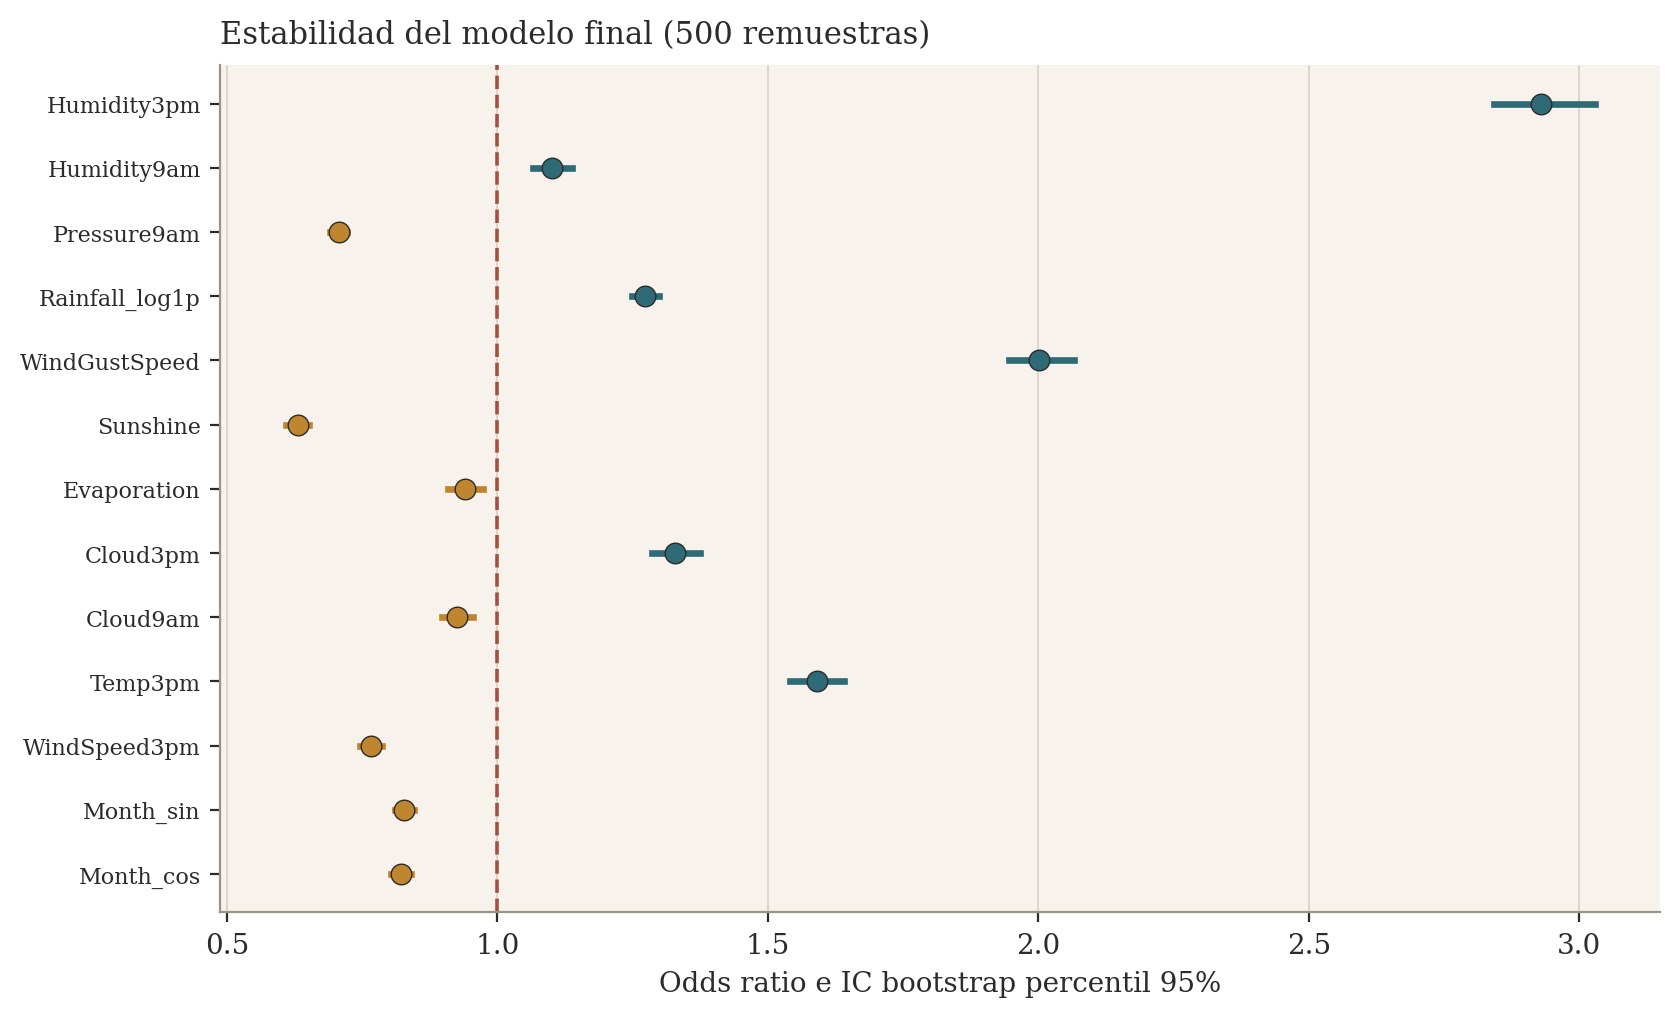

In [5]:
# -----------------------------------------------------------------------------
# 4. Estabilidad bootstrap: 500 reajustes de tamaño completo e inferencia sin ponderación
# -----------------------------------------------------------------------------
print('ETAPA 4: estabilidad bootstrap', flush=True)
B_BOOT = 500
X_boot = X_train_all[FINAL_FEATURES].to_numpy()
n_train = len(y_train)

def ajustar_una_remuestra_bootstrap(seed_boot: int) -> np.ndarray:
    rng_local = np.random.default_rng(seed_boot)
    idx = rng_local.integers(0, n_train, n_train)
    model = LogisticRegression(
        C=1e6,
        solver='liblinear',
        max_iter=300,
        tol=1e-5,
    )
    model.fit(X_boot[idx], y_train[idx])
    return np.concatenate(([model.intercept_[0]], model.coef_[0]))

semillas_bootstrap = rng.integers(0, np.iinfo(np.int32).max, size=B_BOOT)
n_trabajos = min(4, os.cpu_count() or 1)
boot = np.vstack(
    Parallel(
        n_jobs=n_trabajos,
        prefer='threads',
        batch_size=10,
        verbose=5,
    )(
        delayed(ajustar_una_remuestra_bootstrap)(int(seed))
        for seed in semillas_bootstrap
    )
)

inference_final = final['inference']
wald_ci = inference_final.conf_int()
bootstrap_rows = []
for i, variable in enumerate(['const'] + FINAL_FEATURES):
    values = boot[:, i]
    coef_low, coef_high = np.percentile(values, [2.5, 97.5])
    or_values = np.exp(values); or_low, or_high = np.percentile(or_values, [2.5, 97.5])
    bootstrap_rows.append([
        variable, float(inference_final.params[i]), float(wald_ci.iloc[i, 0]), float(wald_ci.iloc[i, 1]),
        float(np.mean(values)), float(coef_low), float(coef_high), float(np.exp(inference_final.params[i])),
        float(or_low), float(or_high), not (coef_low <= 0 <= coef_high),
    ])
bootstrap_stability = pd.DataFrame(bootstrap_rows, columns=[
    'variable', 'coef_modelo', 'coef_wald_inf', 'coef_wald_sup', 'coef_boot_media',
    'coef_boot_inf', 'coef_boot_sup', 'OR_modelo', 'OR_boot_inf', 'OR_boot_sup', 'estable'
])
print('Bootstrap completado', flush=True)
bootstrap_stability.to_csv(TABLES / 's3_10_bootstrap_estabilidad.csv', index=False)
pd.DataFrame(boot, columns=['const'] + FINAL_FEATURES).to_csv(TABLES / 's3_11_bootstrap_coeficientes_raw.csv', index=False)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_df = bootstrap_stability[bootstrap_stability['variable'] != 'const'].copy()
y_positions = np.arange(len(plot_df))[::-1]
for (_, row), y_pos in zip(plot_df.iterrows(), y_positions):
    color = TEAL if row['OR_modelo'] > 1 else OCHRE
    ax.plot([row['OR_boot_inf'], row['OR_boot_sup']], [y_pos, y_pos], color=color, lw=2.4)
    ax.scatter(row['OR_modelo'], y_pos, color=color, s=55, edgecolor=INK, lw=0.5, zorder=3)
ax.axvline(1, color=BRICK, ls='--', lw=1.3)
ax.set_yticks(y_positions); ax.set_yticklabels(plot_df['variable'], fontsize=8)
ax.set_xlabel('Odds ratio e IC bootstrap percentil 95%')
ax.set_title(f'Estabilidad del modelo final ({B_BOOT} remuestras)')
ax.grid(axis='x', color=GRIDC, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout(); fig.savefig(FIGS / 's3_fig5_bootstrap_or.png', bbox_inches='tight'); plt.close(fig)


print('Estabilidad bootstrap del modelo final:')
display(bootstrap_stability)
display(Image(filename=str(FIGS/'s3_fig5_bootstrap_or.png')))


## 2.5 Diagnóstico de supuestos

Se revisan multicolinealidad mediante VIF, linealidad en el logit con términos tipo Box–Tidwell, residuos de devianza y Pearson, leverage y distancia de Cook. Estos diagnósticos siguen el enfoque de regresión logística de Hosmer, Lemeshow y Sturdivant (2013).

La no linealidad detectada no se oculta ni se interpreta como invalidación automática del modelo: se registra como limitación de la forma funcional y como justificación para explorar splines o modelos no lineales.


ETAPA 5: diagnósticos


VIF del modelo final:


,variable,VIF
0,Humidity3pm,2.787079
1,Humidity9am,2.612374
2,Pressure9am,1.529929
3,Rainfall_log1p,1.354150
4,WindGustSpeed,2.567743
5,Sunshine,3.948054
6,Evaporation,2.431538
7,Cloud3pm,2.558207
8,Cloud9am,2.404934
9,Temp3pm,2.932930


Linealidad en el logit:


,variable,p_value_xlogx,lectura
0,Humidity3pm,8.288594e-04,posible no linealidad
1,Humidity9am,8.923276e-01,sin evidencia fuerte
2,Pressure9am,6.371249e-02,sin evidencia fuerte
3,Rainfall_log1p,3.902609e-03,posible no linealidad
4,WindGustSpeed,3.153500e-01,sin evidencia fuerte
5,Sunshine,1.177350e-04,posible no linealidad
6,Evaporation,9.781291e-06,posible no linealidad
7,Cloud3pm,3.729431e-02,posible no linealidad
8,Cloud9am,1.458758e-03,posible no linealidad
9,Temp3pm,6.178542e-08,posible no linealidad


Influencia y residuos:


,estadistico,valor
0,n_muestra,25000.000000
1,pct_pearson_abs_gt3,2.044000
2,cook_max,0.002759
3,cook_p99,0.000413
4,pct_cook_gt_4_n,7.792000
5,leverage_max,0.025426
6,deviance_media,-0.112341
7,deviance_sd,0.838796


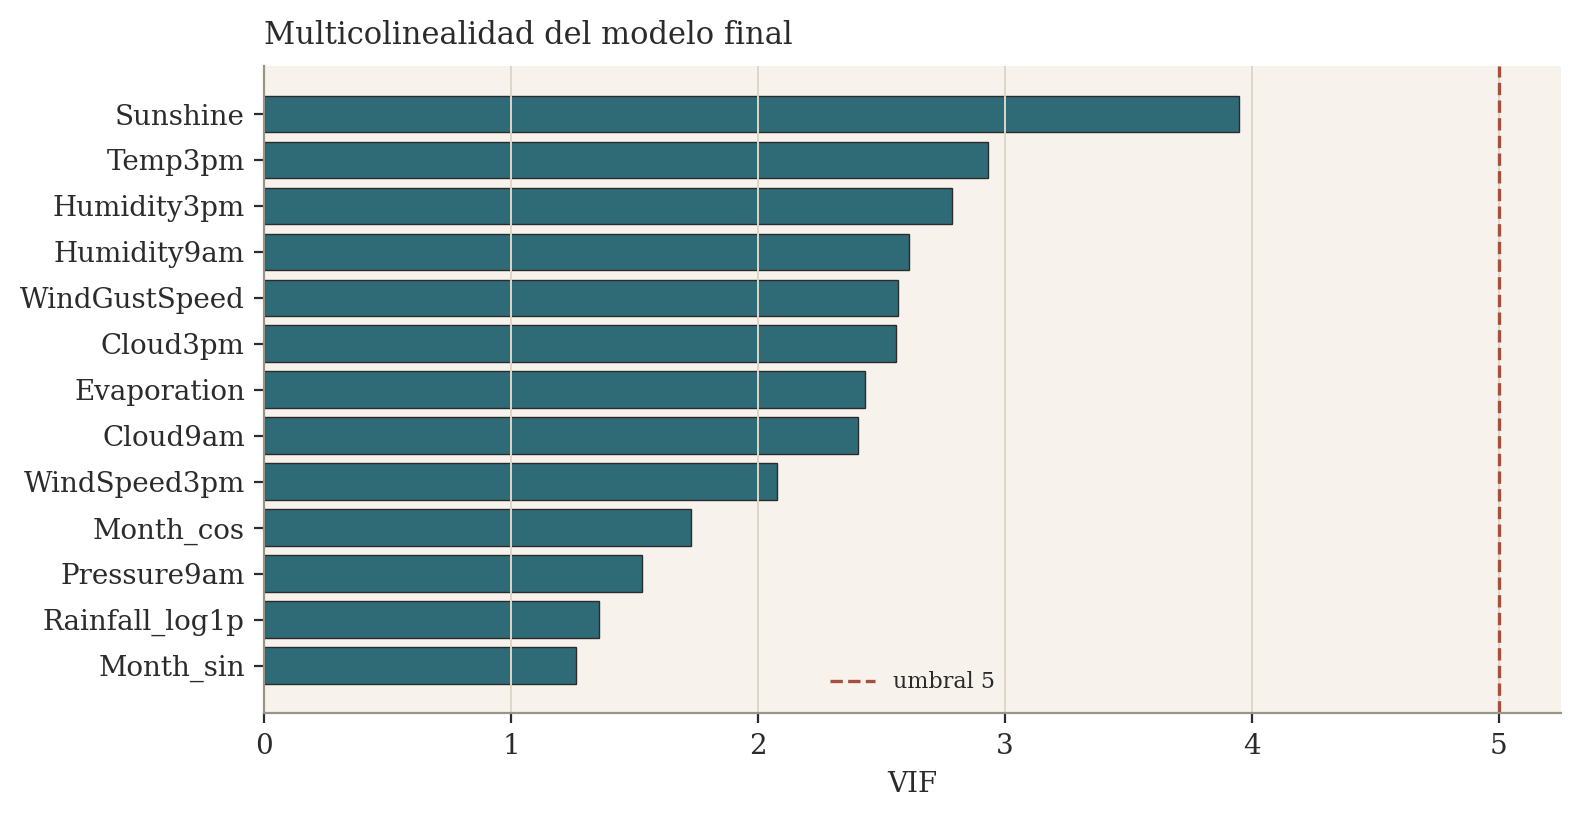

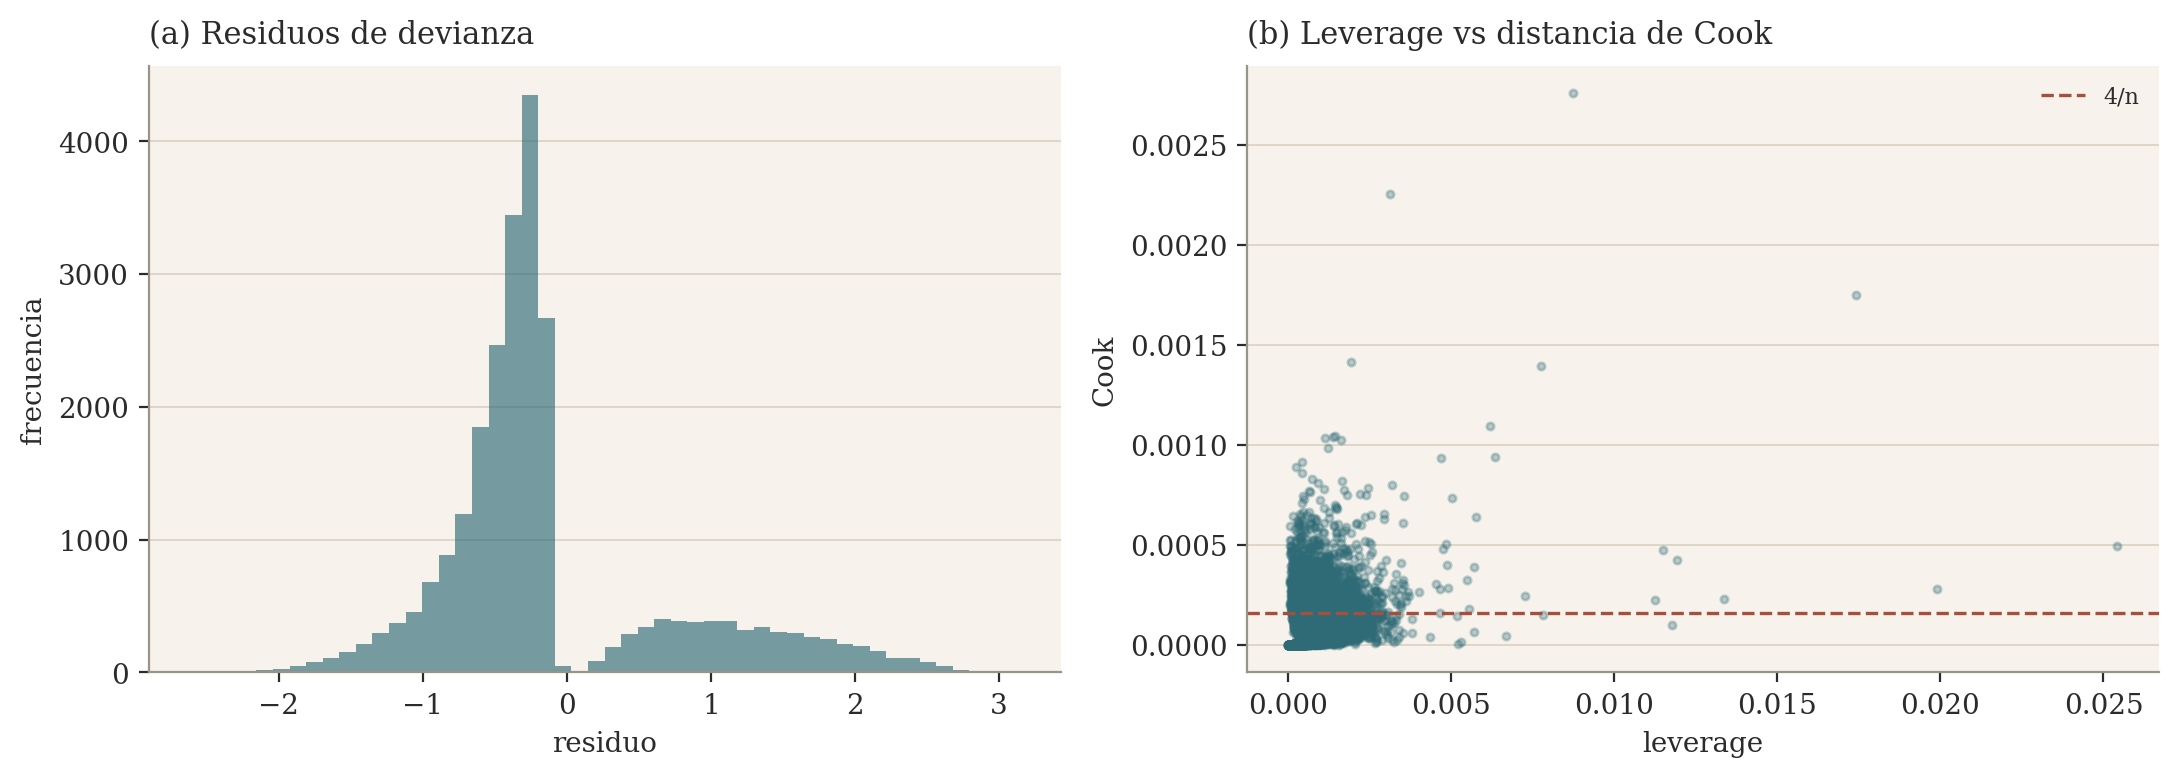

In [6]:
# -----------------------------------------------------------------------------
# 5. Diagnósticos
# -----------------------------------------------------------------------------
print('ETAPA 5: diagnósticos', flush=True)
vif_final = calcular_vif(X_train_all, FINAL_FEATURES).rename('VIF').reset_index().rename(columns={'index': 'variable'})
vif_final.to_csv(TABLES / 's3_12_vif_final.csv', index=False)

# Diagnóstico tipo Box–Tidwell sobre una muestra reproducible; todas las variables finales de M2 son continuas.
bt_n = min(25000, len(y_train)); bt_idx = rng.choice(len(y_train), bt_n, replace=False)
X_bt = X_train_all.iloc[bt_idx][FINAL_FEATURES].copy(); y_bt = y_train[bt_idx]
bt_rows = []
for variable in FINAL_FEATURES:
    shifted = X_bt[variable].to_numpy() - X_bt[variable].min() + 1e-3
    X_temp = X_bt.copy(); term = f'{variable}_xlogx'; X_temp[term] = shifted * np.log(shifted)
    try:
        result = sm.GLM(y_bt, sm.add_constant(X_temp, has_constant='add'), family=sm.families.Binomial()).fit(maxiter=100, disp=0)
        p_value = float(result.pvalues[term])
        bt_rows.append([variable, p_value, 'posible no linealidad' if p_value < 0.05 else 'sin evidencia fuerte'])
    except Exception:
        bt_rows.append([variable, np.nan, 'no estimado'])
box_tidwell = pd.DataFrame(bt_rows, columns=['variable', 'p_value_xlogx', 'lectura'])
box_tidwell.to_csv(TABLES / 's3_13_linealidad_logit.csv', index=False)

# Influencia y residuos calculados sobre una muestra para controlar el uso de memoria.
inf_n = min(25000, len(y_train)); inf_idx = rng.choice(len(y_train), inf_n, replace=False)
X_inf = X_train_all.iloc[inf_idx][FINAL_FEATURES]; y_inf = y_train[inf_idx]
glm_inf = sm.GLM(y_inf, sm.add_constant(X_inf, has_constant='add'), family=sm.families.Binomial()).fit()
influence = glm_inf.get_influence(observed=True)
cooks = influence.cooks_distance[0]; leverage = influence.hat_matrix_diag
pearson = glm_inf.resid_pearson; deviance = glm_inf.resid_deviance
influence_summary = pd.DataFrame({
    'estadistico': ['n_muestra', 'pct_pearson_abs_gt3', 'cook_max', 'cook_p99', 'pct_cook_gt_4_n', 'leverage_max', 'deviance_media', 'deviance_sd'],
    'valor': [inf_n, np.mean(np.abs(pearson) > 3) * 100, np.max(cooks), np.quantile(cooks, 0.99),
              np.mean(cooks > 4 / inf_n) * 100, np.max(leverage), np.mean(deviance), np.std(deviance)]
})
influence_summary.to_csv(TABLES / 's3_14_influencia_residuos.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(deviance, bins=50, color=TEAL, alpha=0.65)
axes[0].set_title('(a) Residuos de devianza'); axes[0].set_xlabel('residuo'); axes[0].set_ylabel('frecuencia'); aplicar_rejilla_horizontal(axes[0])
axes[1].scatter(leverage, cooks, s=7, alpha=0.3, color=TEAL)
axes[1].axhline(4 / inf_n, color=BRICK, ls='--', lw=1.2, label='4/n')
axes[1].set_title('(b) Leverage vs distancia de Cook'); axes[1].set_xlabel('leverage'); axes[1].set_ylabel('Cook')
axes[1].legend(frameon=False, fontsize=8); aplicar_rejilla_horizontal(axes[1])
fig.tight_layout(); fig.savefig(FIGS / 's3_fig6_residuos_influencia.png', bbox_inches='tight'); plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4.2))
vif_plot = vif_final.sort_values('VIF')
ax.barh(vif_plot['variable'], vif_plot['VIF'], color=TEAL, edgecolor=INK, lw=0.5)
ax.axvline(5, color=BRICK, ls='--', lw=1.2, label='umbral 5')
ax.set_xlabel('VIF'); ax.set_title('Multicolinealidad del modelo final')
ax.legend(frameon=False, fontsize=8); ax.grid(axis='x', color=GRIDC, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout(); fig.savefig(FIGS / 's3_fig7_vif.png', bbox_inches='tight'); plt.close(fig)


print('VIF del modelo final:')
display(vif_final)
print('Linealidad en el logit:')
display(box_tidwell)
print('Influencia y residuos:')
display(influence_summary)
display(Image(filename=str(FIGS/'s3_fig7_vif.png')))
display(Image(filename=str(FIGS/'s3_fig6_residuos_influencia.png')))


# Parte 3. Impacto de la estrategia de imputación

El modelo final se reajusta sobre los tres datasets. Se comparan tamaño muestral, coeficientes e intervalos de confianza, AUC, accuracy, recall, F1 y PR-AUC en prueba temporal. La eliminación puede exhibir un AUC mayor, pero descarta cerca de dos tercios del conjunto de prueba y cambia la población evaluada; por eso ese valor no se interpreta como superioridad causal de la estrategia.


Diagnósticos completados


ETAPA 6: impacto de la imputación


Métricas por estrategia de imputación:


,estrategia,n_train,n_test,accuracy,precision,recall,specificity,f1,auc,pr_auc,tn,fp,fn,tp
0,Eliminación,42964,15195,0.805199,0.526934,0.742117,0.822048,0.616282,0.870990,0.681236,9858,2134,826,2377
1,Imputación simple,93076,49117,0.794246,0.518407,0.714259,0.816381,0.600774,0.849512,0.652606,31407,7064,3042,7604
2,Imputación por regresión,93076,49117,0.784677,0.502222,0.743190,0.796158,0.599394,0.851827,0.655475,30629,7842,2734,7912


Coeficientes e IC por estrategia:


,modelo,variable,coef,IC95_coef_inf,IC95_coef_sup,OR,IC95_OR_inf,IC95_OR_sup,p_value
0,Eliminación,const,-1.962768,-2.000933,-1.924602,0.140469,0.135209,0.145934,0.000000e+00
1,Eliminación,Humidity3pm,1.099919,1.050683,1.149155,3.003923,2.859604,3.155525,0.000000e+00
2,Eliminación,Humidity9am,0.061176,0.010457,0.111896,1.063086,1.010512,1.118397,1.807685e-02
3,Eliminación,Pressure9am,-0.352029,-0.388111,-0.315947,0.703260,0.678337,0.729098,1.653426e-81
4,Eliminación,Rainfall_log1p,0.188243,0.159085,0.217401,1.207127,1.172438,1.242842,1.069417e-36
5,Eliminación,WindGustSpeed,0.779817,0.734812,0.824822,2.181073,2.085090,2.281476,8.472226e-253
6,Eliminación,Sunshine,-0.579906,-0.631460,-0.528353,0.559951,0.531815,0.589575,1.023009e-107
7,Eliminación,Evaporation,-0.146699,-0.197294,-0.096104,0.863554,0.820949,0.908370,1.324592e-08
8,Eliminación,Cloud3pm,0.325030,0.275865,0.374194,1.384072,1.317670,1.453819,2.132442e-38
9,Eliminación,Cloud9am,-0.123166,-0.170781,-0.075552,0.884117,0.843006,0.927232,3.980243e-07


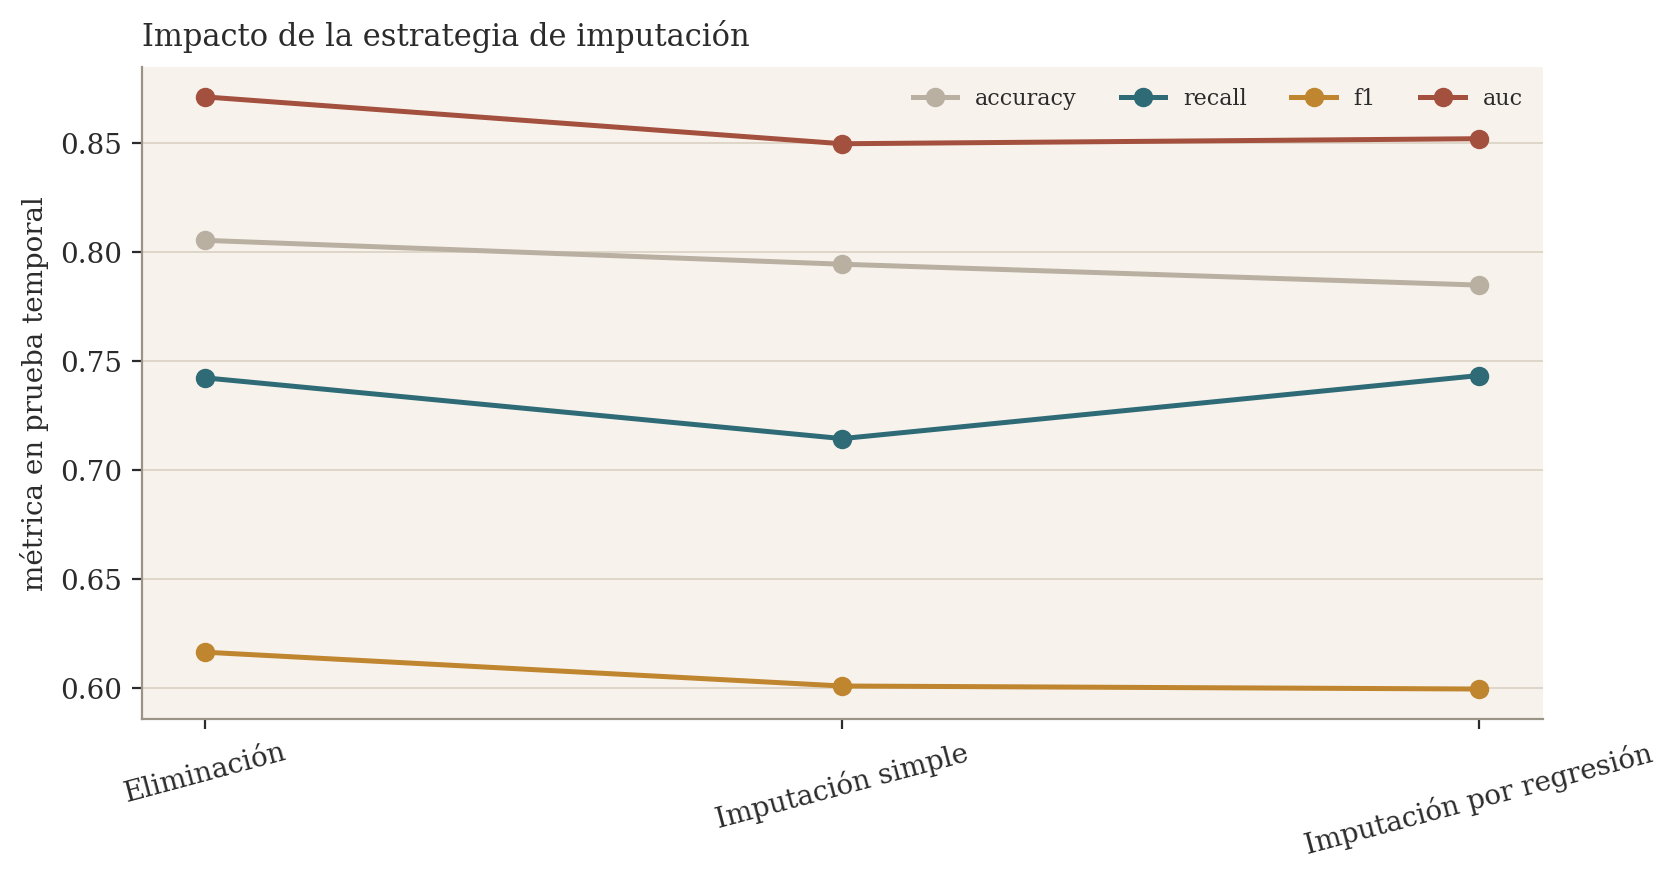

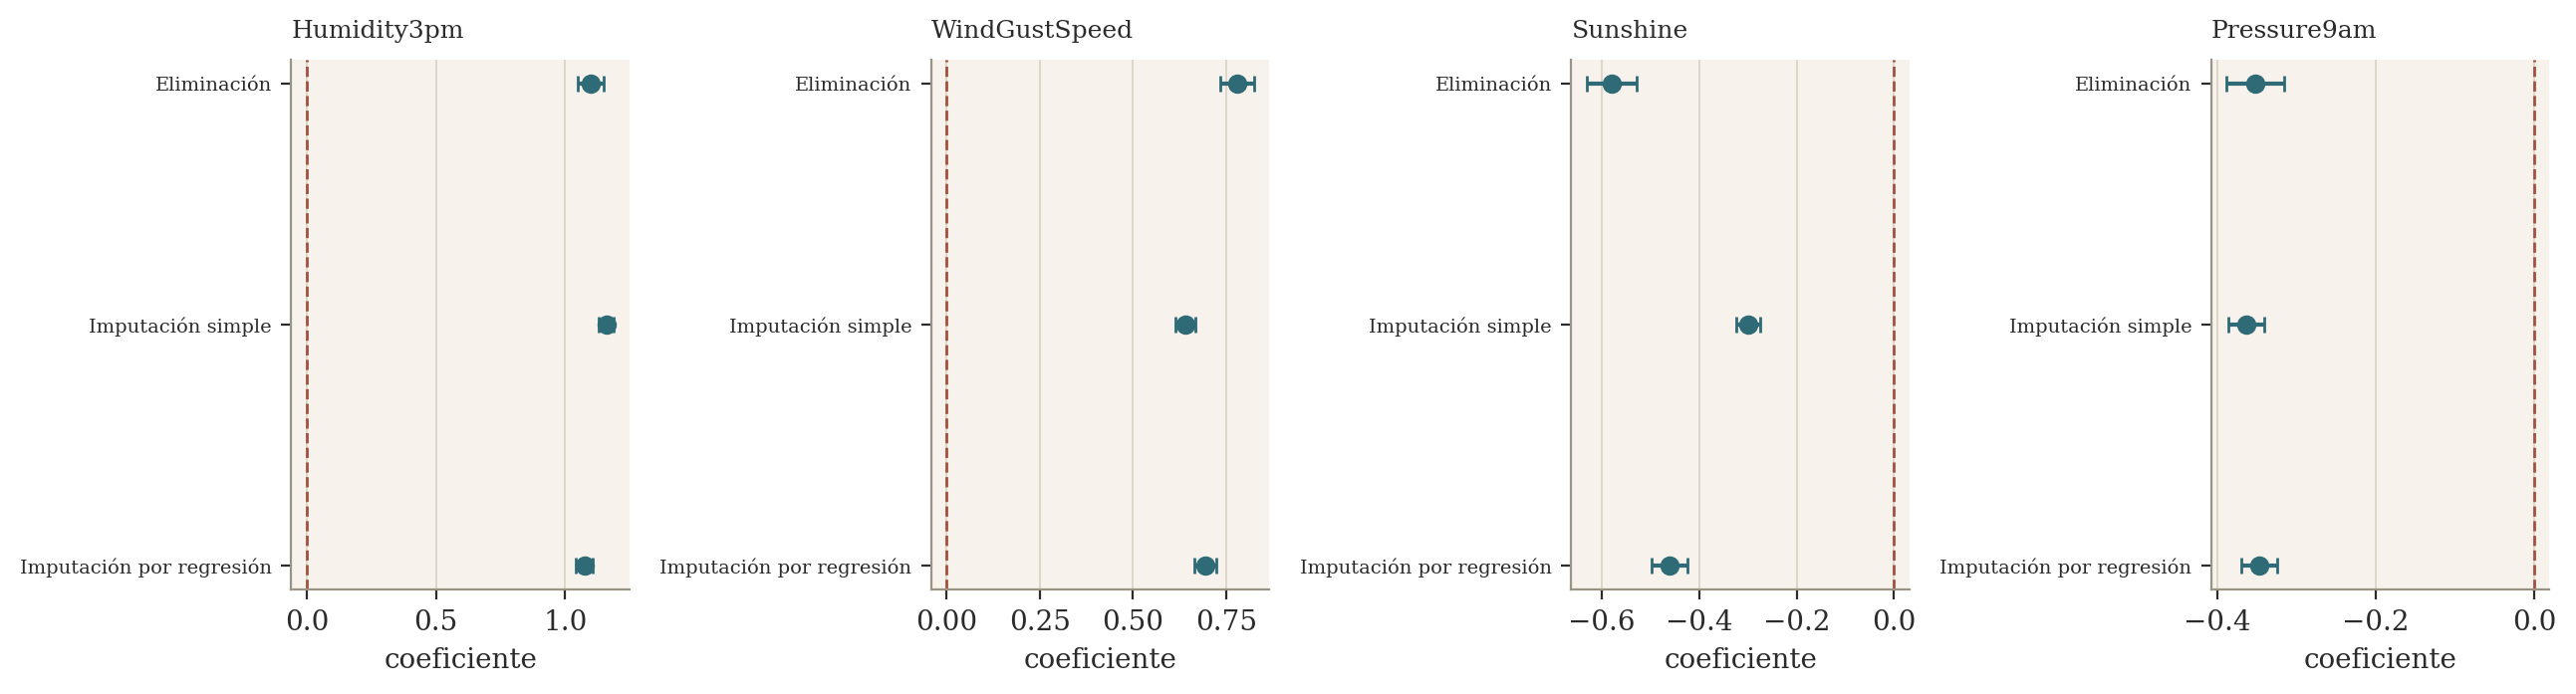

In [7]:
# -----------------------------------------------------------------------------
# 6. Impacto sistemático de la imputación sobre el modelo final
# -----------------------------------------------------------------------------
print('Diagnósticos completados', flush=True)
print('ETAPA 6: impacto de la imputación', flush=True)
def ajustar_modelo_final_por_estrategia(strategy_name: str, train: pd.DataFrame, test: pd.DataFrame, drop_missing: bool):
    Xtr, Xte, ytr, yte, _, _, _ = preprocesar_estrategia(train, test, FINAL_FEATURES, drop_missing=drop_missing)
    infer = ajustar_logit_inferencia(Xtr, ytr, FINAL_FEATURES)
    pred_model = LogisticRegression(
        C=1e6,
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced',
        tol=1e-5,
    )
    pred_model.fit(Xtr[FINAL_FEATURES], ytr)
    pte = pred_model.predict_proba(Xte[FINAL_FEATURES])[:, 1]
    metrics = calcular_metricas_clasificacion(yte, pte)
    row = {'estrategia': strategy_name, 'n_train': len(ytr), 'n_test': len(yte), **metrics}
    coef = crear_tabla_coeficientes(infer, strategy_name)
    return row, coef

impact_rows = []; impact_coef_tables = []
for name, tr, te, drop_flag in [
    ('Eliminación', train_drop, test_drop, True),
    ('Imputación simple', train_simple, test_simple, False),
    ('Imputación por regresión', train_reg, test_reg, False),
]:
    row, coef = ajustar_modelo_final_por_estrategia(name, tr, te, drop_flag)
    impact_rows.append(row); impact_coef_tables.append(coef)
impact_metrics = pd.DataFrame(impact_rows)
impact_coefficients = pd.concat(impact_coef_tables, ignore_index=True)
impact_metrics.to_csv(TABLES / 's3_15_impacto_imputacion_metricas.csv', index=False)
impact_coefficients.to_csv(TABLES / 's3_16_impacto_imputacion_coeficientes.csv', index=False)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for metric, color in zip(['accuracy', 'recall', 'f1', 'auc'], [STEM, TEAL, OCHRE, BRICK]):
    ax.plot(impact_metrics['estrategia'], impact_metrics[metric], marker='o', lw=1.8, color=color, label=metric)
ax.set_ylabel('métrica en prueba temporal'); ax.set_title('Impacto de la estrategia de imputación')
ax.tick_params(axis='x', rotation=15); ax.legend(frameon=False, ncol=4, fontsize=8); aplicar_rejilla_horizontal(ax)
fig.tight_layout(); fig.savefig(FIGS / 's3_fig8_impacto_imputacion.png', bbox_inches='tight'); plt.close(fig)

# Figura comparativa de coeficientes para cuatro variables interpretables.
key_variables = [v for v in ['Humidity3pm', 'WindGustSpeed', 'Sunshine', 'Pressure9am'] if v in FINAL_FEATURES]
fig, axes = plt.subplots(1, len(key_variables), figsize=(13, 3.6), sharey=False)
if len(key_variables) == 1:
    axes = [axes]
for ax, variable in zip(axes, key_variables):
    sub = impact_coefficients[impact_coefficients['variable'] == variable].copy()
    y_pos = np.arange(len(sub))[::-1]
    ax.errorbar(sub['coef'], y_pos,
                xerr=[sub['coef'] - sub['IC95_coef_inf'], sub['IC95_coef_sup'] - sub['coef']],
                fmt='o', color=TEAL, capsize=3)
    ax.axvline(0, color=BRICK, ls='--', lw=1)
    ax.set_yticks(y_pos); ax.set_yticklabels(sub['modelo'], fontsize=7)
    ax.set_title(variable, fontsize=9); ax.set_xlabel('coeficiente')
    ax.grid(axis='x', color=GRIDC, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout(); fig.savefig(FIGS / 's3_fig9_coeficientes_imputacion.png', bbox_inches='tight'); plt.close(fig)


print('Métricas por estrategia de imputación:')
display(impact_metrics)
print('Coeficientes e IC por estrategia:')
display(impact_coefficients)
display(Image(filename=str(FIGS/'s3_fig8_impacto_imputacion.png')))
display(Image(filename=str(FIGS/'s3_fig9_coeficientes_imputacion.png')))


# Parte 4. Informe integrado, discusión y conclusiones

## 4.1 Resumen ejecutivo

El proyecto entrega una línea base logística interpretable para predecir `RainTomorrow`, evaluada sobre el 30 % cronológicamente más reciente. El modelo usa ponderación de clase y se valida mediante particiones temporales internas, además de una prueba temporal externa.

## 4.2 Introducción y objetivo

El objetivo es anticipar lluvia al día siguiente en un conjunto desbalanceado, con faltantes extensos y dependencia temporal y espacial. El modelo debe apoyar decisiones meteorológicas u operativas, no reemplazar el juicio experto.

## 4.3 Metodología integrada S1 → S2 → S3

S1 caracterizó faltantes, outliers, correlaciones y desbalance. S2 verificó estabilidad mediante bootstrap y permutación, diagnosticó la cero-inflación de `Rainfall` y advirtió dependencia por `Location`. S3 transforma esa evidencia en imputación por regresión, `log1p(Rainfall)`, control VIF, selección por dominio/stepwise/BIC, bootstrap de coeficientes y evaluación temporal externa.

## 4.4 Resultados y discusión crítica

La especificación final mantiene buena discriminación y sensibilidad a la clase minoritaria. Los coeficientes son estables, pero varias relaciones no son estrictamente lineales en el logit. La imputación por regresión conserva la muestra y la estructura de correlaciones, aunque puede encoger la varianza. La eliminación obtiene resultados sobre una subpoblación distinta y no se interpreta como superioridad general.

## 4.5 Conclusiones y recomendaciones

Se recomienda calibrar el umbral según costos, mantener validación temporal, complementar con validación agrupada por `Location`, evaluar imputación múltiple y explorar splines. El desempeño debe monitorearse en años futuros y por estación.



In [8]:
selected_test = performance[
    (performance["modelo"] == FINAL_MODEL)
    & (performance["particion"] == "test")
].iloc[0]

selected_train = performance[
    (performance["modelo"] == FINAL_MODEL)
    & (performance["particion"] == "train")
].iloc[0]

resumen_final = {
    "dataset_rows_raw": int(len(df_raw)),
    "dataset_rows_target_valid": int(len(df)),
    "positive_rate": float(df["RainTomorrow_bin"].mean()),
    "cutoff_date": cutoff_date.strftime("%Y-%m-%d"),
    "train_n": int(len(train_raw)),
    "test_n": int(len(test_raw)),
    "train_positive_rate": float(train_raw["RainTomorrow_bin"].mean()),
    "test_positive_rate": float(test_raw["RainTomorrow_bin"].mean()),
    "stepwise_features": STEPWISE_FEATURES,
    "bic_features": BIC_FEATURES,
    "automatic_methods_converged": bool(
        set(STEPWISE_FEATURES) == set(BIC_FEATURES)
    ),
    "reduced_features": REDUCED_FEATURES,
    "final_model": FINAL_MODEL,
    "final_features": FINAL_FEATURES,
    "bootstrap_B": B_BOOT,
    "bootstrap_unstable": bootstrap_stability.loc[
        ~bootstrap_stability["estable"], "variable"
    ].tolist(),
    "max_vif": float(vif_final["VIF"].max()),
    "test_metrics": {
        metrica: float(selected_test[metrica])
        for metrica in [
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "auc",
            "pr_auc",
        ]
    },
    "train_metrics": {
        metrica: float(selected_train[metrica])
        for metrica in [
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "auc",
            "pr_auc",
        ]
    },
    "cv_temporal_auc_mean": float(selected_test["cv_temporal_auc_media"]),
    "cv_temporal_auc_sd": float(selected_test["cv_temporal_auc_sd"]),
    "performance_models": performance.to_dict(orient="records"),
    "impact_imputation": impact_metrics.to_dict(orient="records"),
}

ruta_resumen = RESULTS / "s3_summary.json"
with ruta_resumen.open("w", encoding="utf-8") as archivo:
    json.dump(
        resumen_final,
        archivo,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

tabla_indicadores = pd.DataFrame(
    {
        "Indicador": [
            "AUC test",
            "PR-AUC test",
            "Accuracy test",
            "Precision test",
            "Recall test",
            "F1 test",
            "VIF máximo",
            "Bootstrap B",
        ],
        "Valor": [
            resumen_final["test_metrics"]["auc"],
            resumen_final["test_metrics"]["pr_auc"],
            resumen_final["test_metrics"]["accuracy"],
            resumen_final["test_metrics"]["precision"],
            resumen_final["test_metrics"]["recall"],
            resumen_final["test_metrics"]["f1"],
            resumen_final["max_vif"],
            resumen_final["bootstrap_B"],
        ],
    }
)

display(tabla_indicadores.round(3))


,Indicador,Valor
0,AUC test,0.852
1,PR-AUC test,0.655
2,Accuracy test,0.785
3,Precision test,0.502
4,Recall test,0.743
5,F1 test,0.599
6,VIF máximo,3.948
7,Bootstrap B,500.000


# Bibliografía

- Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall.
- Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied logistic regression* (3.ª ed.). Wiley.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning*. Springer.
- Kaggle. (2017). *Rain in Australia* [Conjunto de datos]. https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical analysis with missing data* (3.ª ed.). Wiley.
- Maidana, J. P. (2026). *Selección de variables y comparación de modelos* [Apunte del curso MCDI501]. Universidad Andrés Bello.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96.
